## Setup 

In [150]:
import os
import sys
import math
import json
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg


## Load Data

In [151]:
# load the clean datasets

df = pd.read_csv("clean_data.csv")
df.sample()
df.columns

Index(['census_tract', 'StCoFIPS2019', 'StAbbr', 'walkability_index',
       'Pop2018', 'HU2018', 'HH2018', 'employment_mix',
       'employment_residential_mix', 'intersection_density',
       'transit_accessibility', 'employment_mix_ranked',
       'employment_residential_mix_ranked', 'intersection_density_ranked',
       'transit_accessibility_ranked', 'median_income', 'percent_unemployed',
       'percent_below_poverty', 'percent_bachelor_and_higher',
       'percent_over_65', 'percent_commute_car', 'percent_commute_transit',
       'percent_white', 'percent_black', 'percent_native_american',
       'percent_asian', 'percent_pacific_islander', 'statedesc', 'countyname',
       'total_population', 'arthritis_crudeprev', 'arthritis_crude95ci',
       'high_blood_pressure_prevalence', 'high_blood_pressure_95ci',
       'cancer_prevalence', 'cancer_95ci', 'current_asthma_prevalence',
       'current_asthma_95ci', 'coronary_heart_disease_prevalence',
       'coronary_heart_disease_95ci'

## Whisker Plots

Here, we will plot whisker plots to understand to get the idea for correlation for different health outcomes and use the walkability index to get the crude idea of the relationship between health indicators and walkability.

In [152]:
#health outcomes to be studied

health_outcomes_columns = [
    'obesity_prevalence',
    'diabetes_prevalence',
    'high_blood_pressure_prevalence',
    'depression_prevalence',
    'high_cholesterol_prevalence',
    'cancer_prevalence',
    'current_asthma_prevalence',
    'coronary_heart_disease_prevalence',
    'stroke_prevalence'
]

walkability_features = ['walkability_index','employment_mix_ranked',
       'employment_residential_mix_ranked', 'intersection_density_ranked',
       'transit_accessibility_ranked']

obesity_prevalence


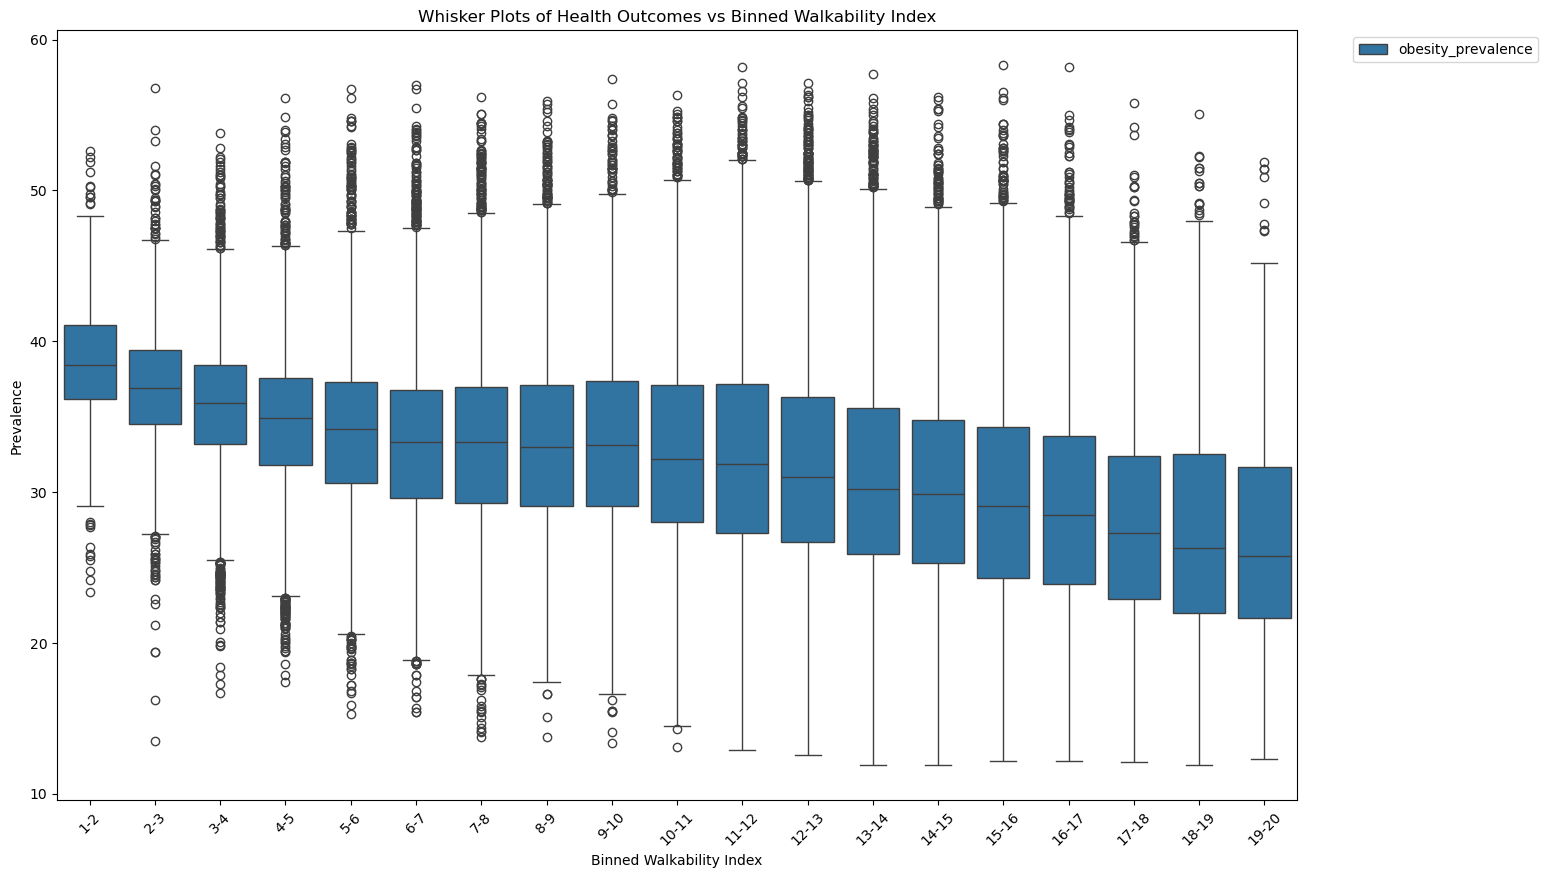

diabetes_prevalence


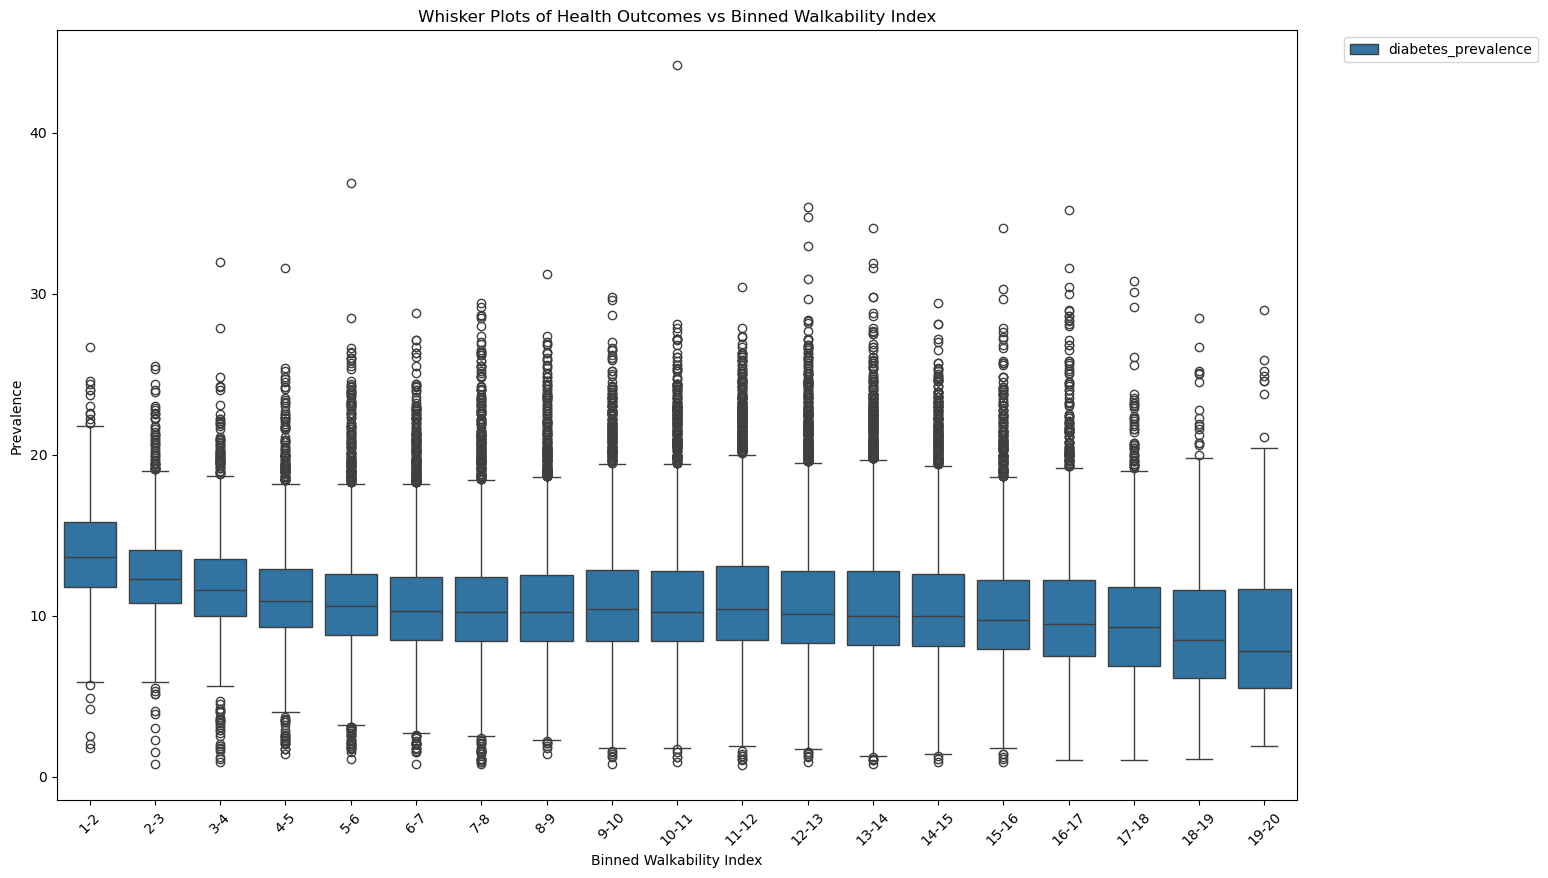

high_blood_pressure_prevalence


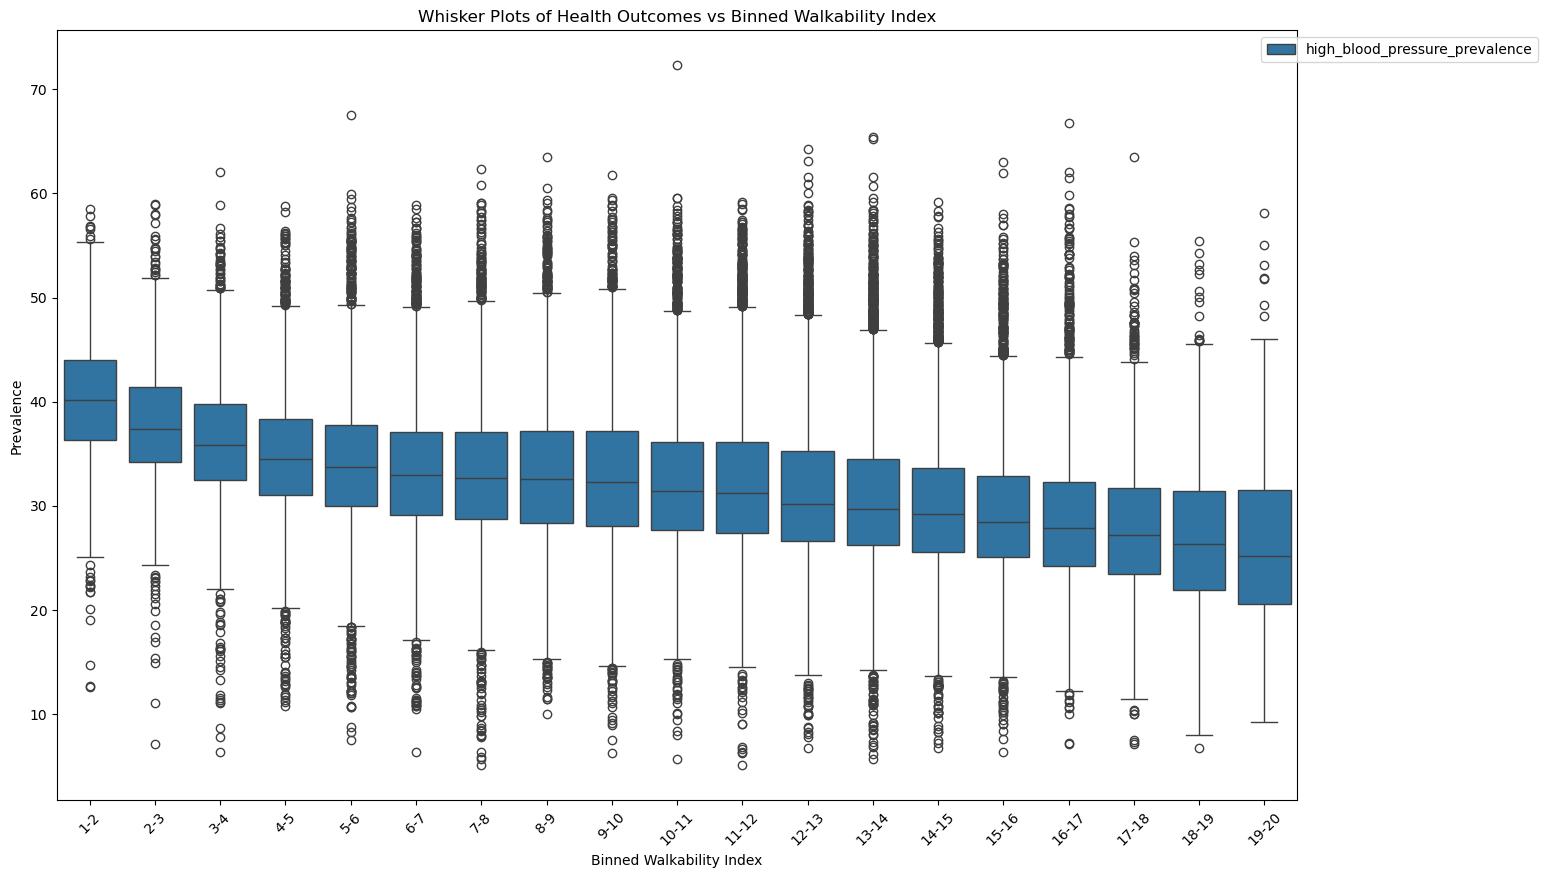

depression_prevalence


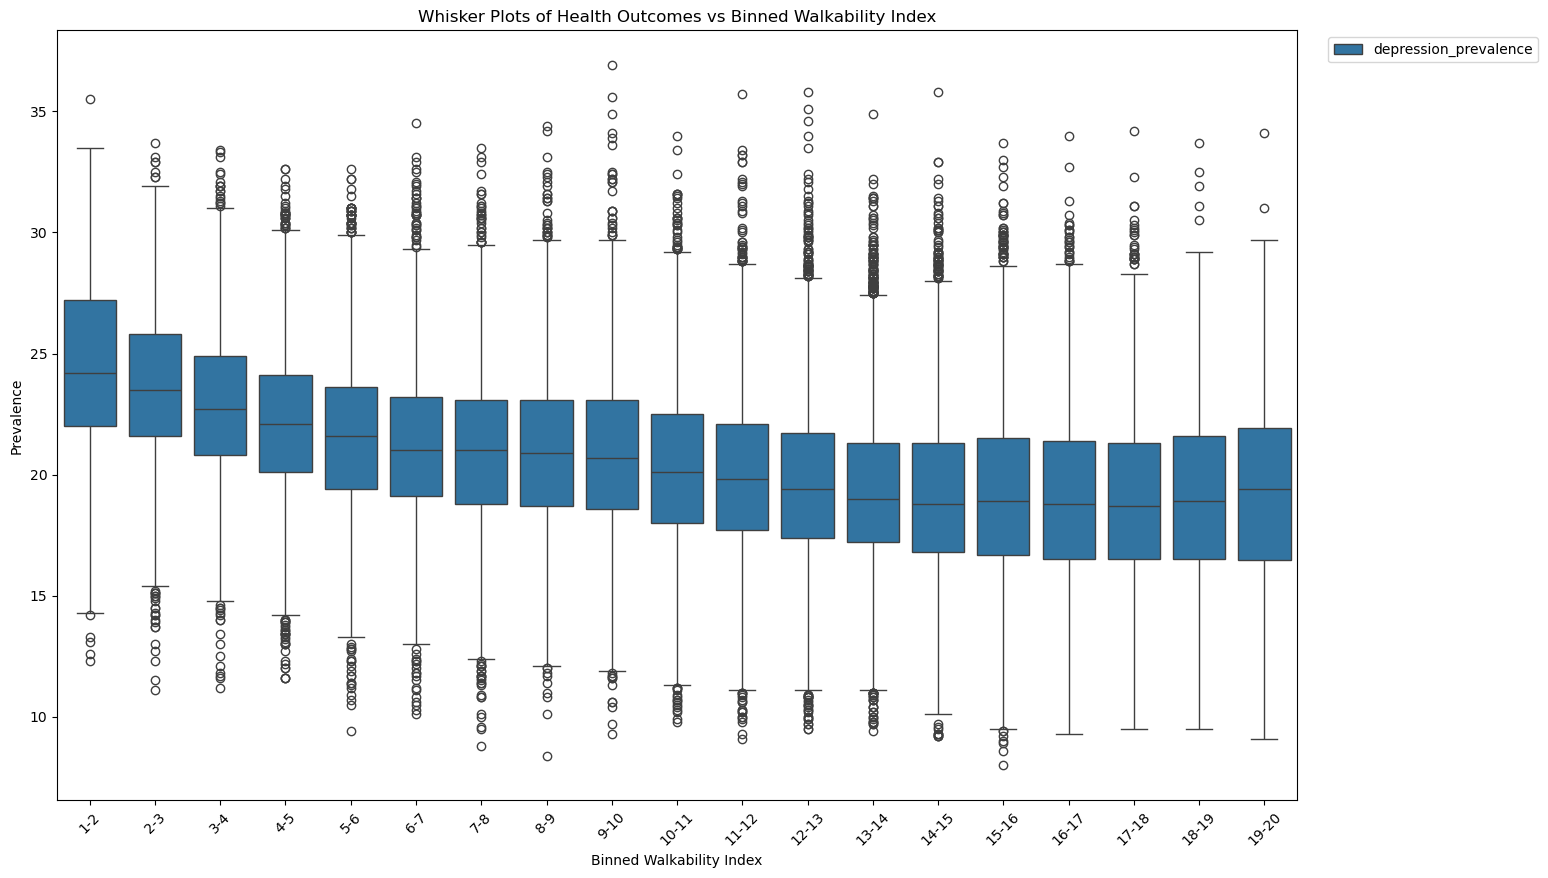

high_cholesterol_prevalence


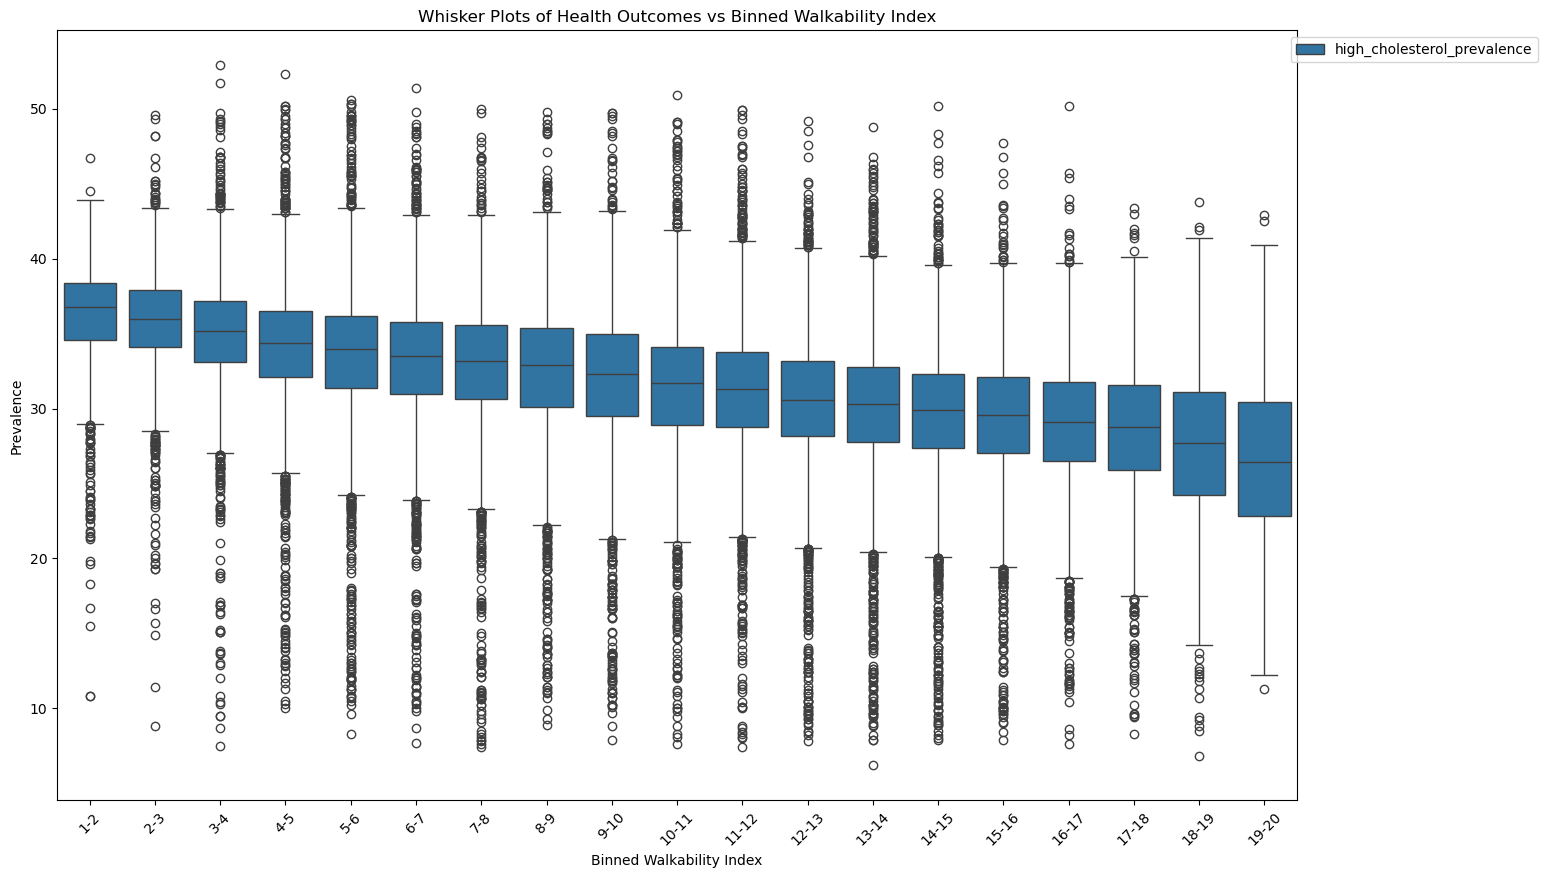

cancer_prevalence


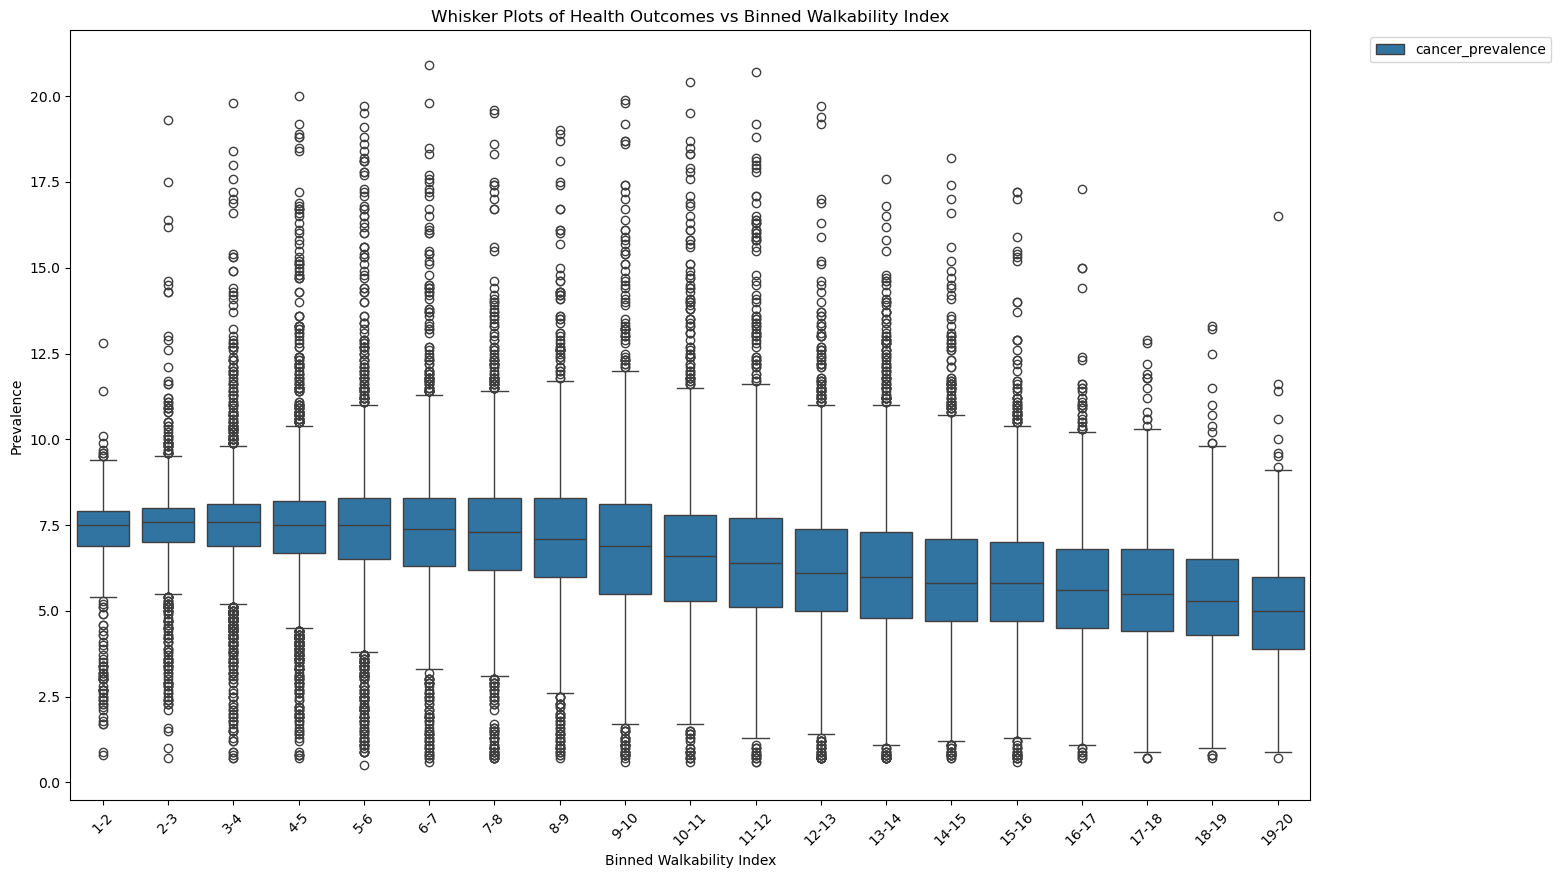

current_asthma_prevalence


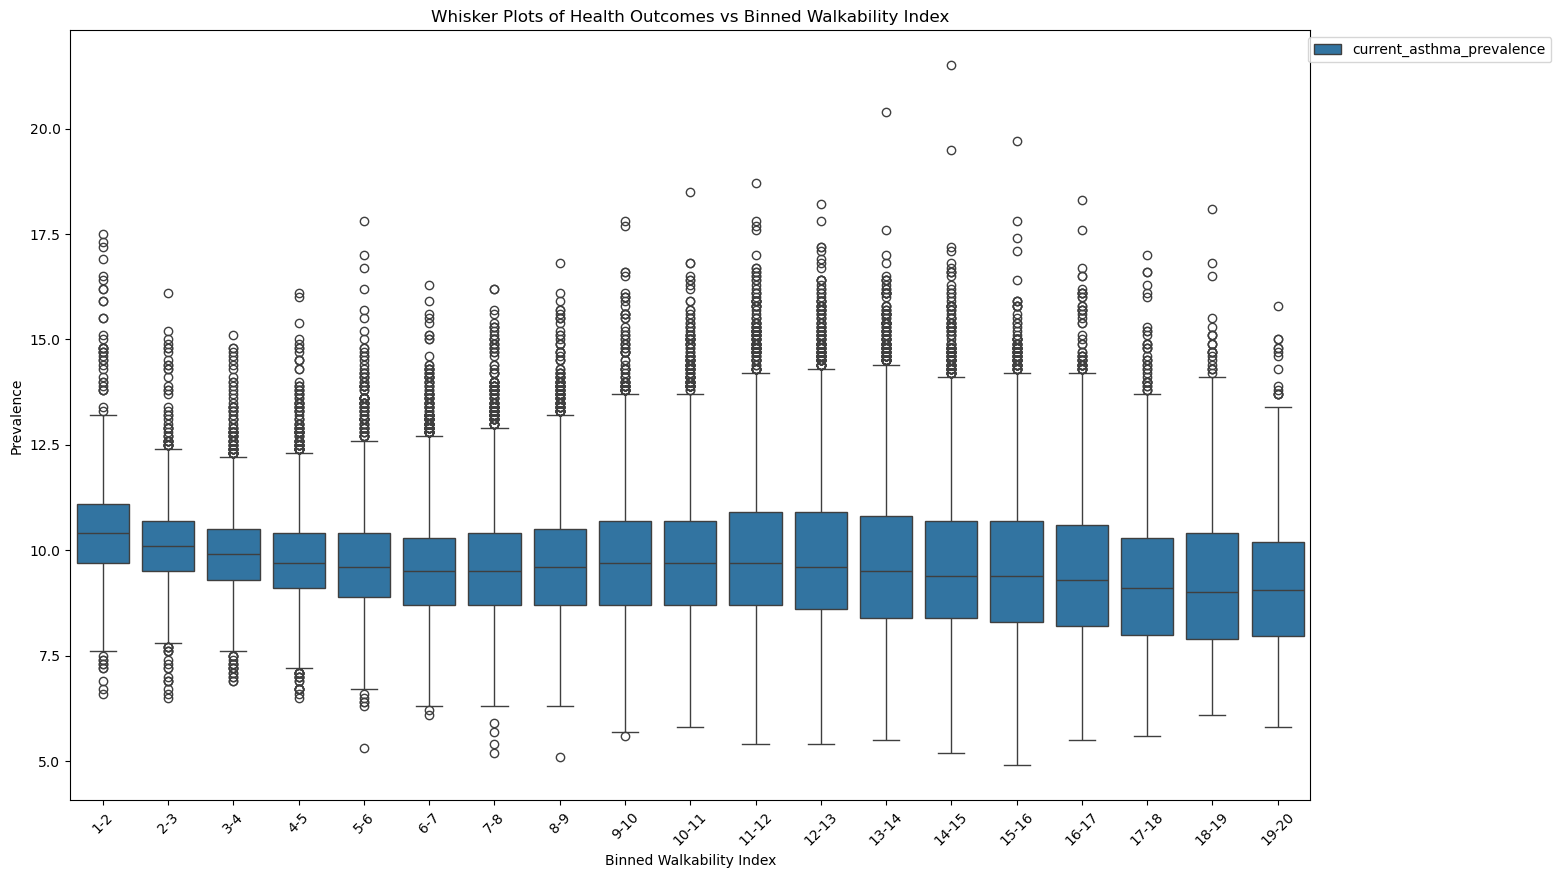

coronary_heart_disease_prevalence


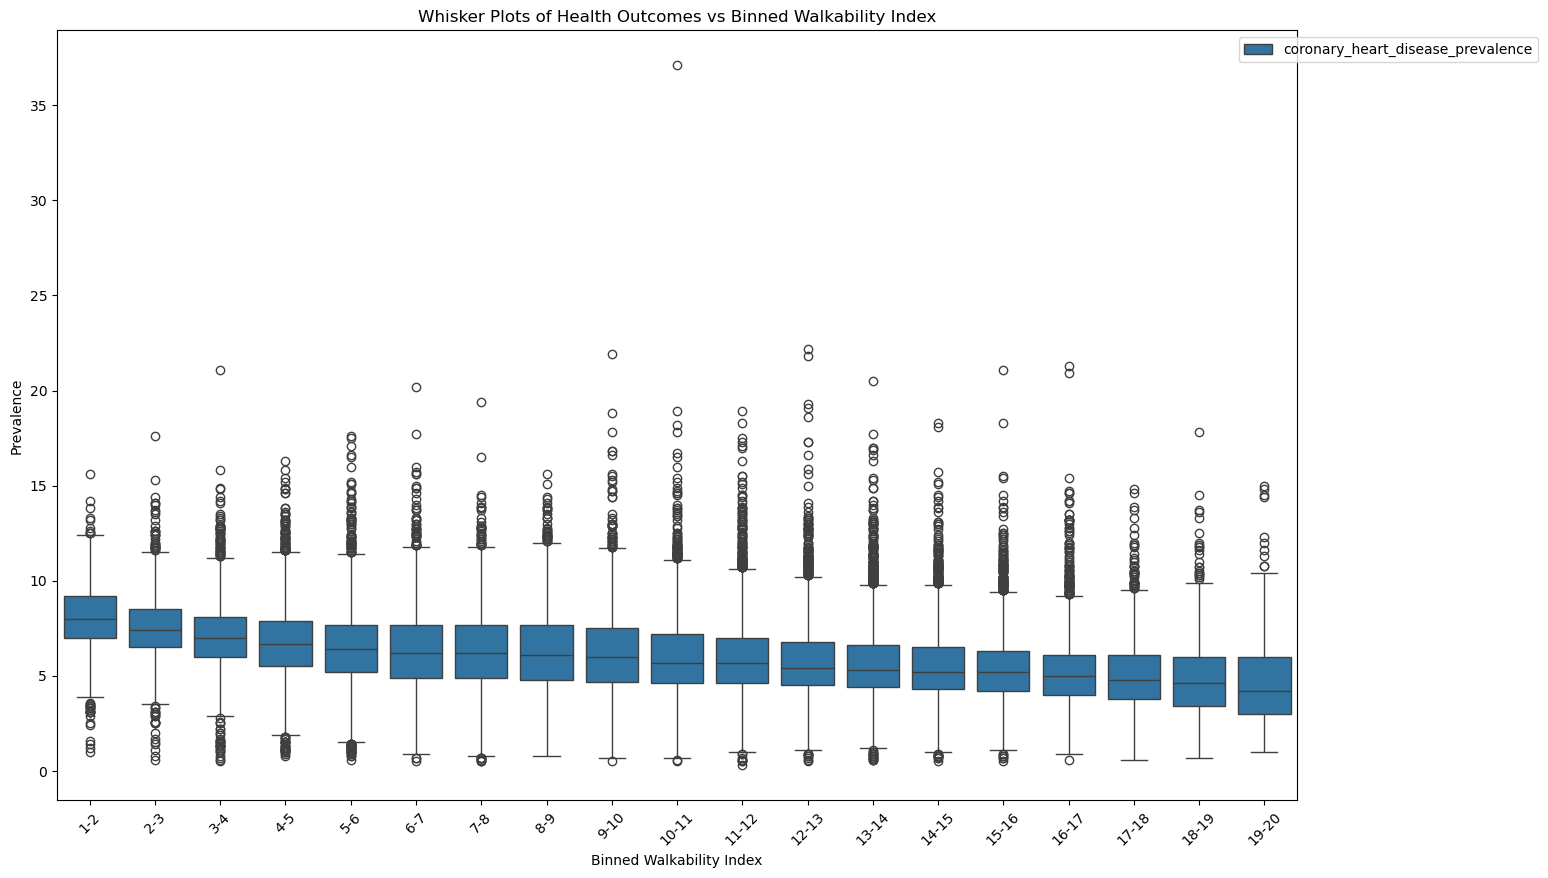

stroke_prevalence


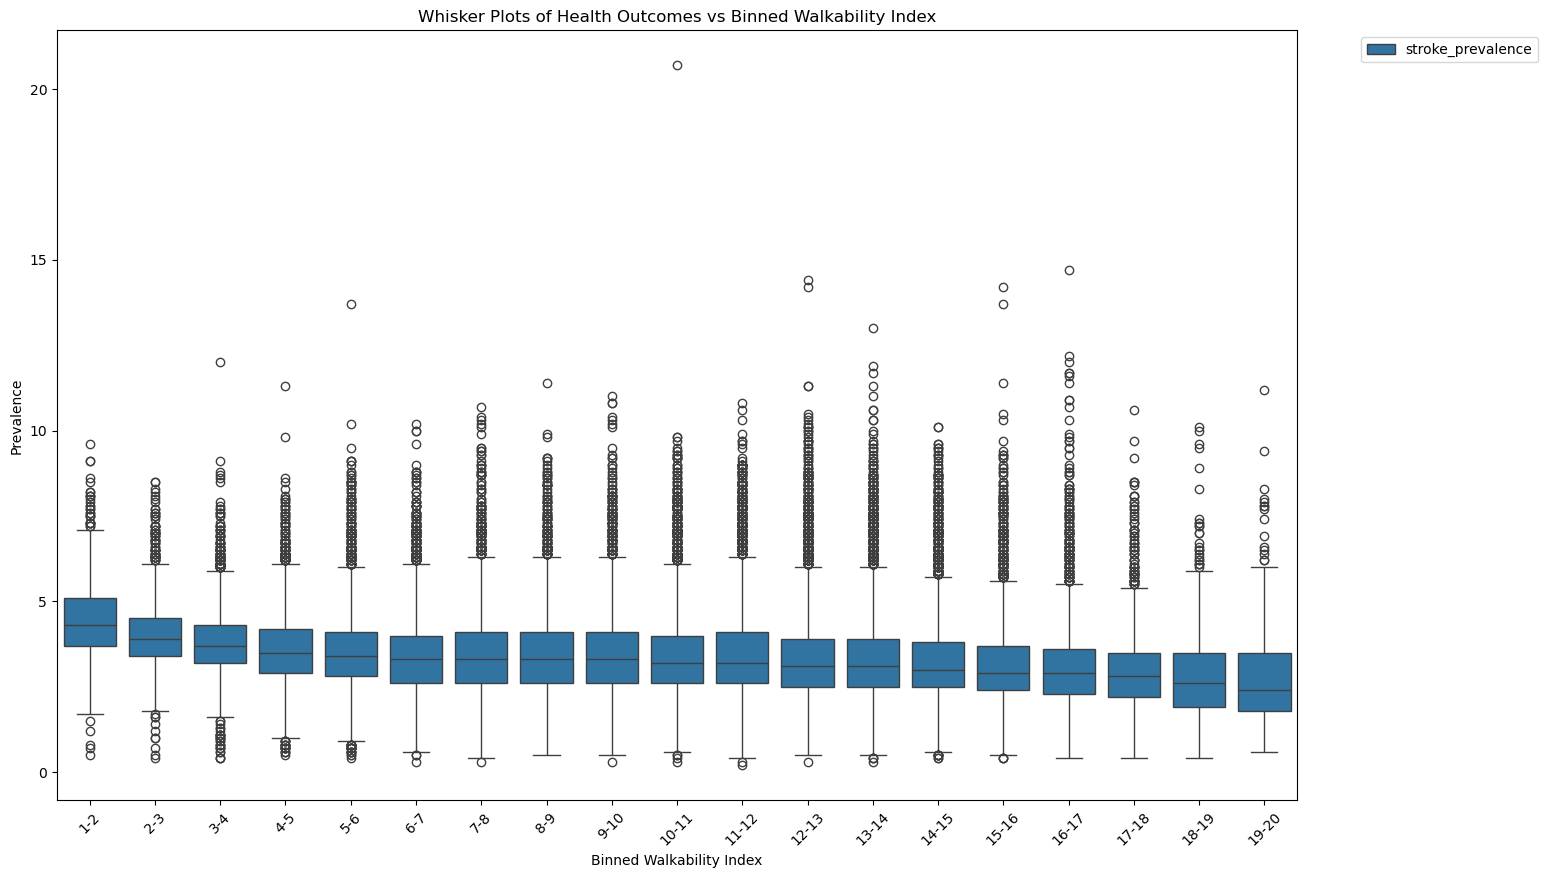

In [61]:
# Bin the `walkability_index` into intervals from 1-2, 2-3, ..., up to 20
bins = [i for i in range(1, 21)]  # Create bins from 1 to 21
bin_labels = [f"{i}-{i+1}" for i in range(1, 20)]  # Create labels like 1-2, 2-3, ..., 19-20

for i in health_outcomes_columns:
    print(i)
    # Create a new column for the binned walkability index
    df['walkability_index_bin'] = pd.cut(df['walkability_index'], bins=bins, labels=bin_labels, right=False)

    # Reshape the data into a long format to plot all health outcomes together
    df_long = df.melt(id_vars=["walkability_index_bin"], value_vars= i, 
                  var_name="health_outcome", value_name="prevalence")

# Plot the whisker plots for health outcomes across binned walkability index
    plt.figure(figsize=(16, 10))
    sns.boxplot(x="walkability_index_bin", y="prevalence", hue="health_outcome", data=df_long)

# Improve readability
    plt.xticks(rotation=45)  # Rotate x-axis labels for clarity
    plt.title("Whisker Plots of Health Outcomes vs Binned Walkability Index")
    plt.xlabel("Binned Walkability Index")
    plt.ylabel("Prevalence")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()


From the boxplots above, we see that for health outcomes: high cholestrol, obesity, high blood pressure, depression, the mean prevelance decreases as walkability increases. However, the skewness/ deviation also increases with increase in walkability. This depicts a mild inverse correlation between given helth outcomes and walkability. We more robustly verify this point looking at the partial correlations in the next section.

### Box plots for employment mixing

obesity_prevalence


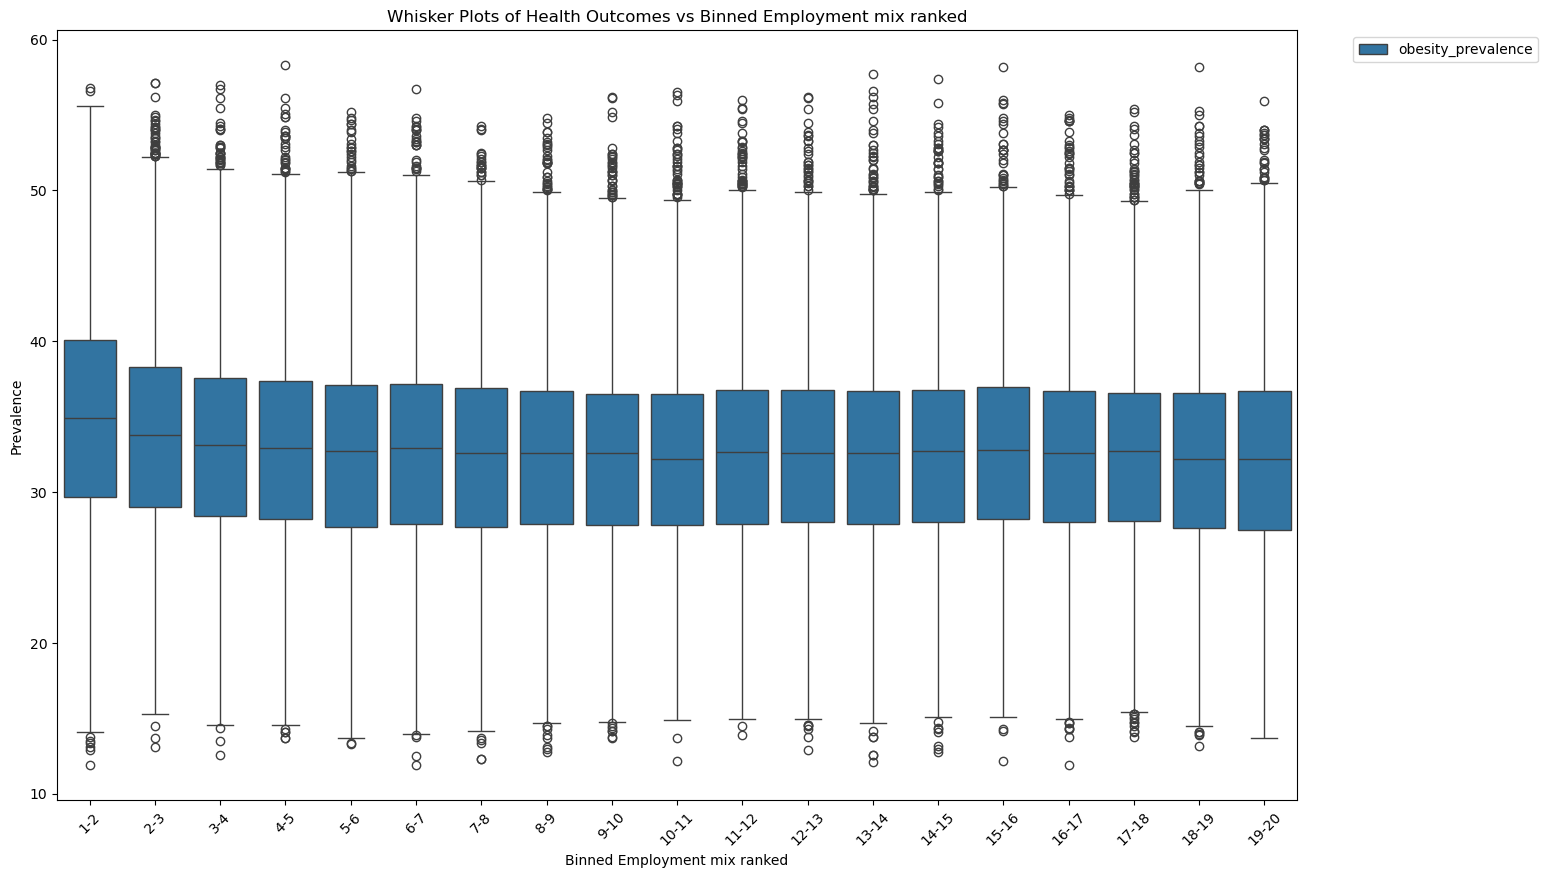

diabetes_prevalence


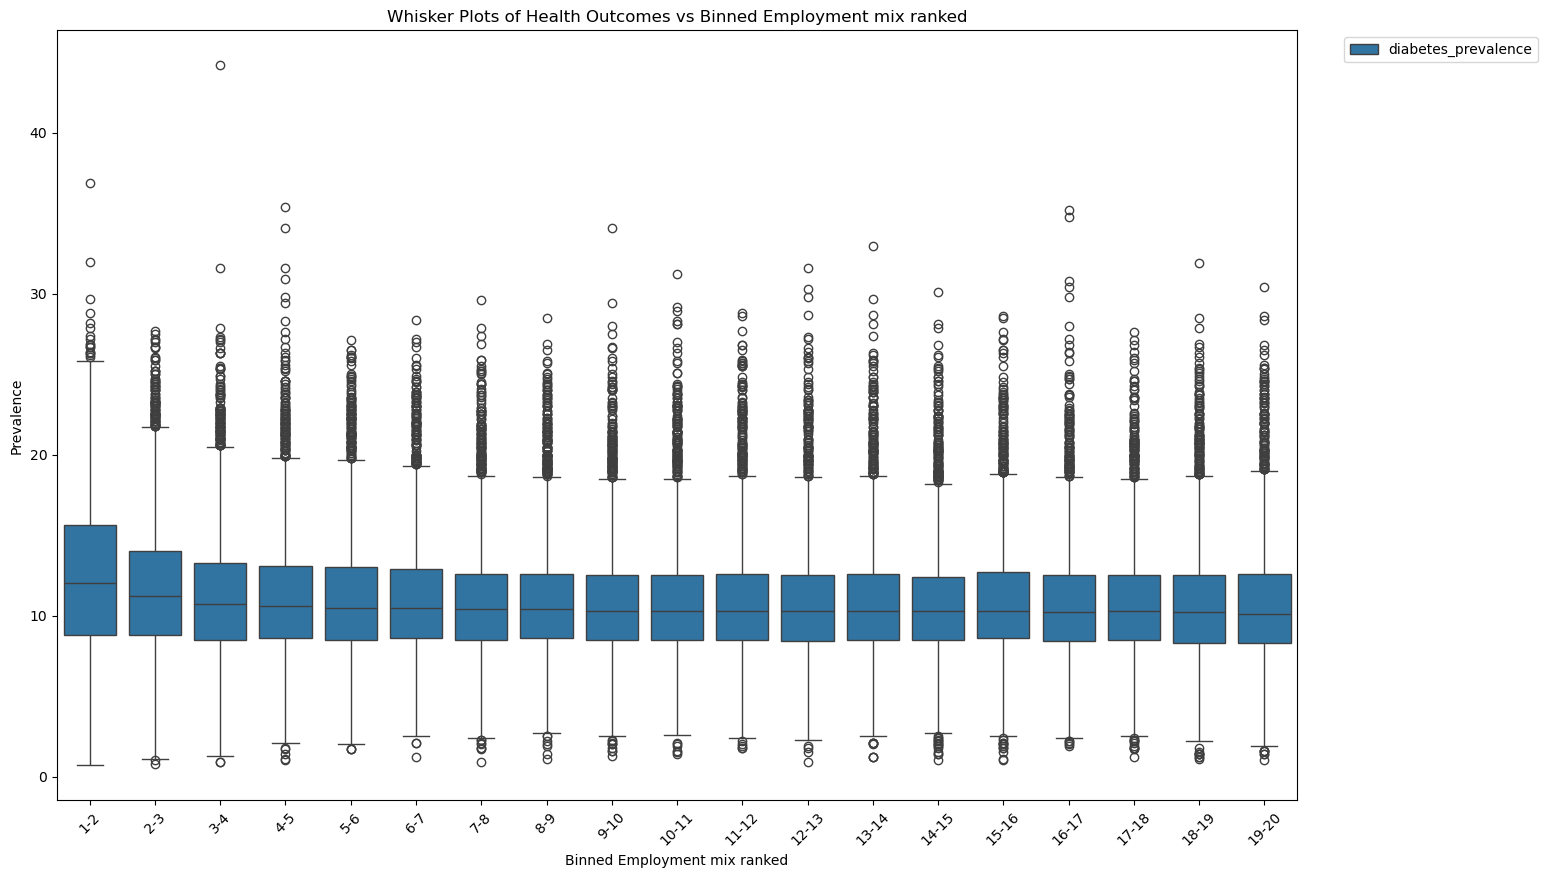

high_blood_pressure_prevalence


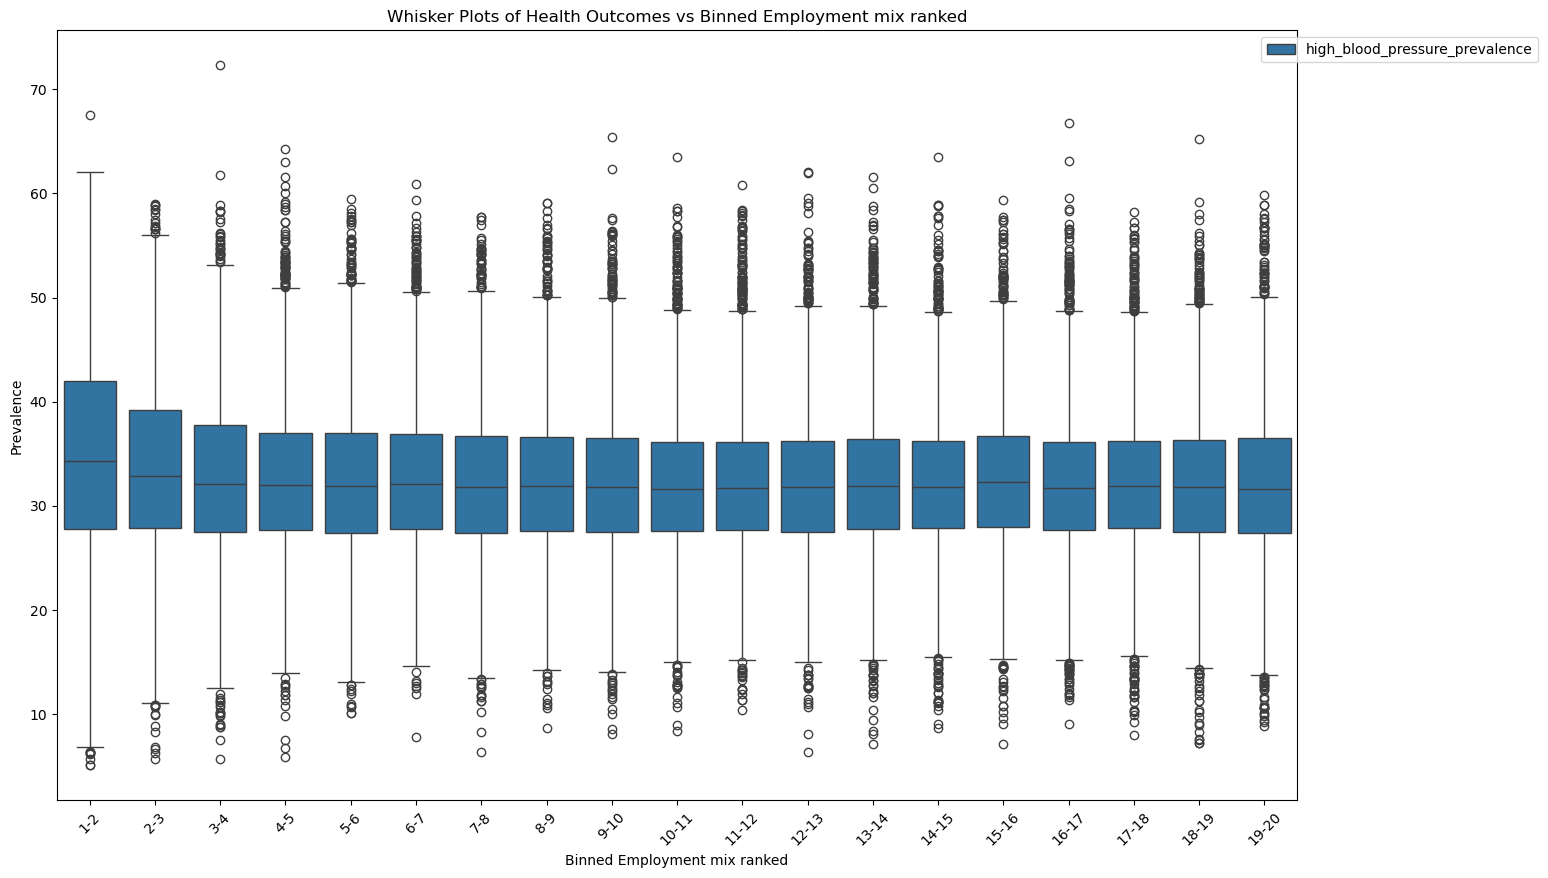

depression_prevalence


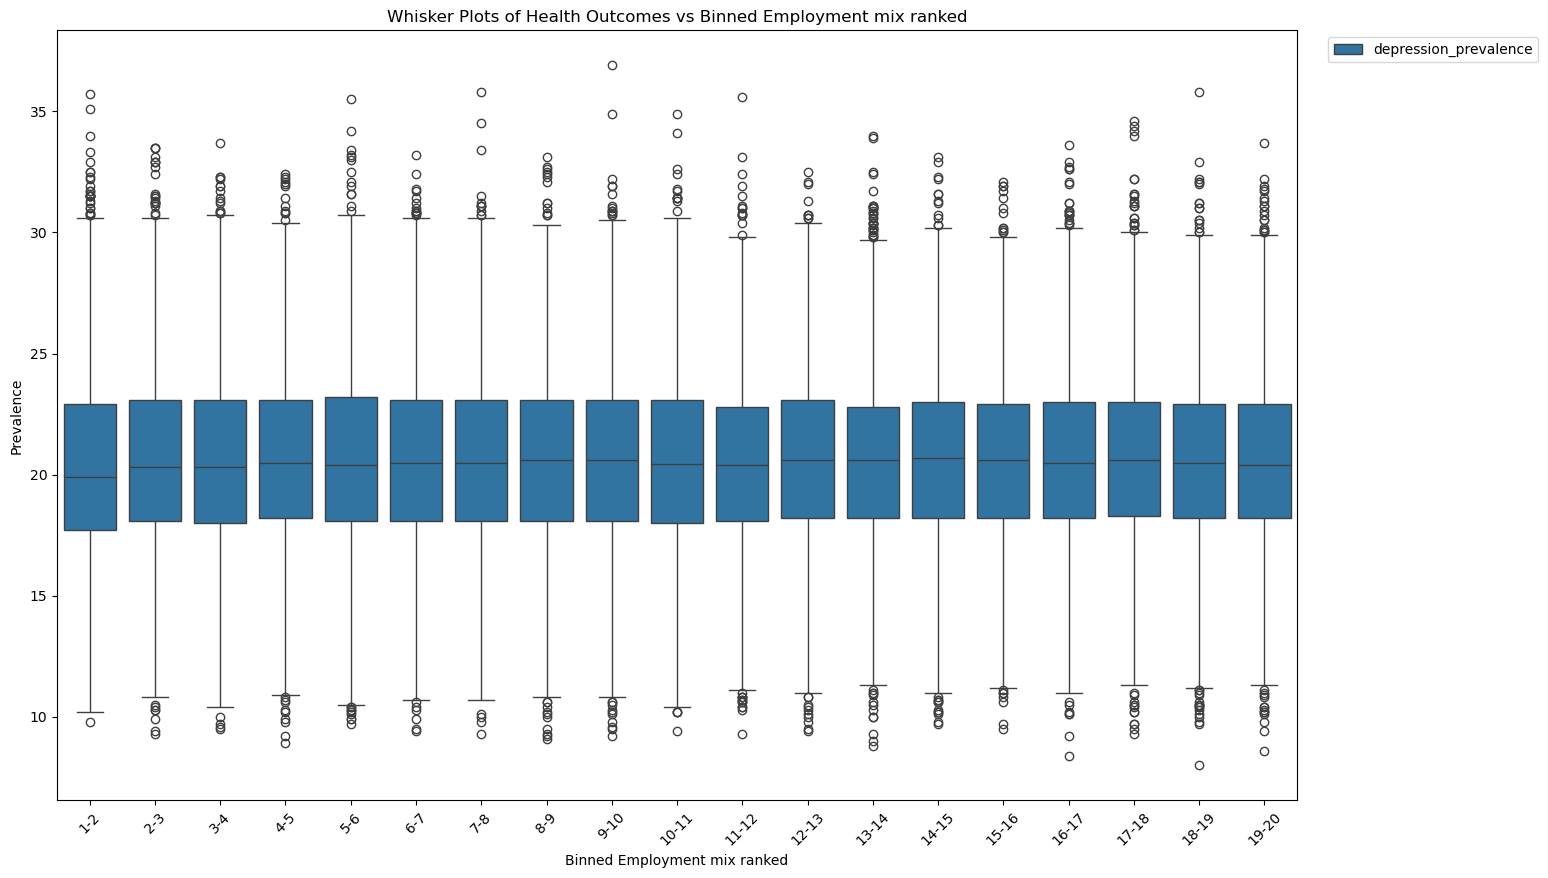

high_cholesterol_prevalence


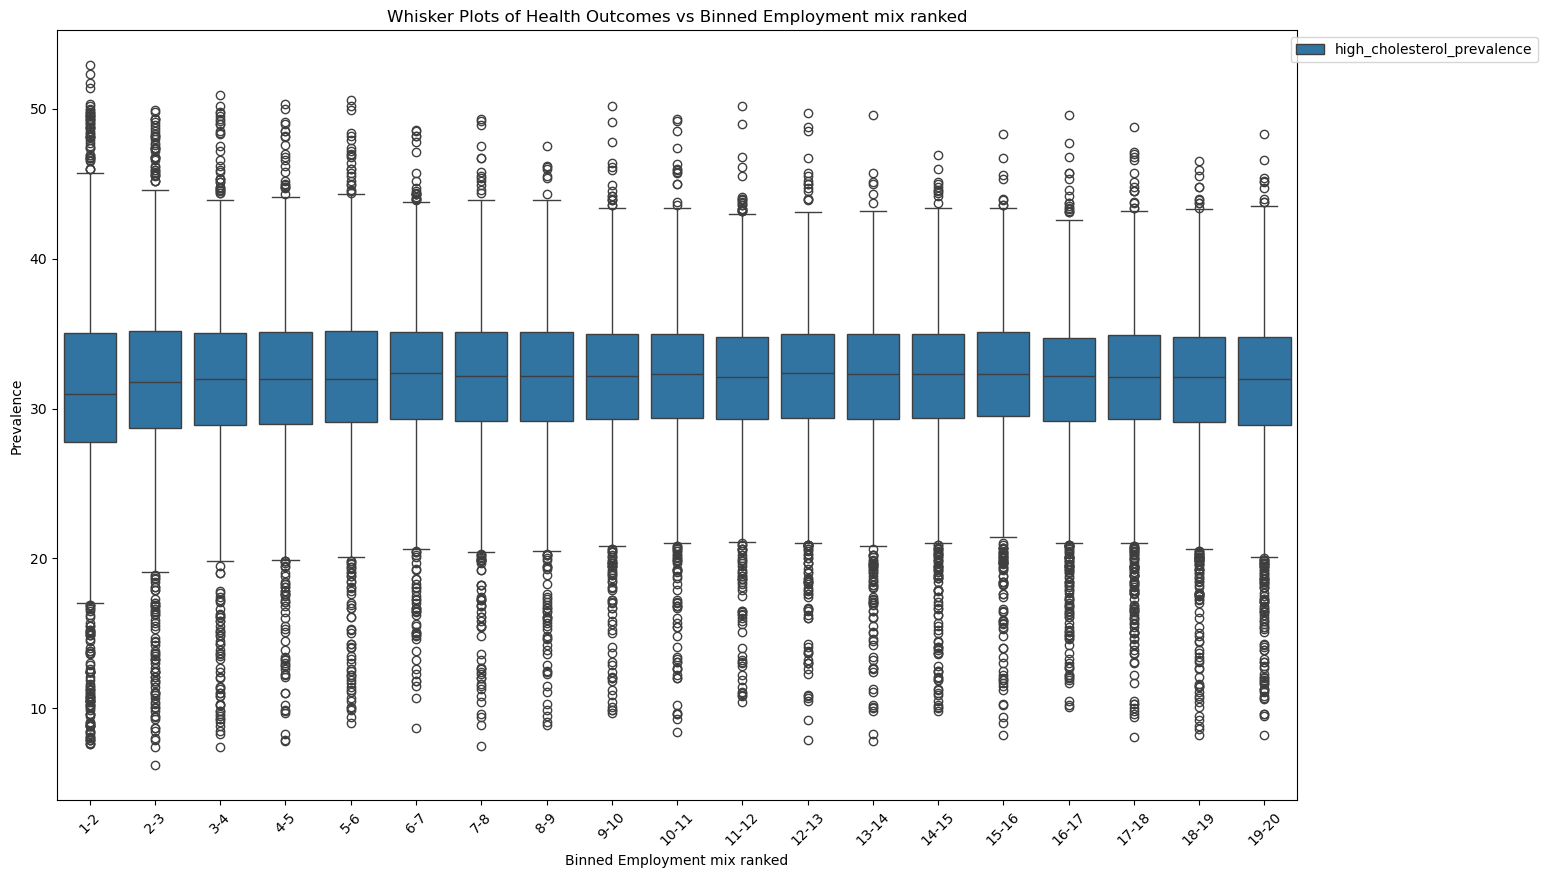

cancer_prevalence


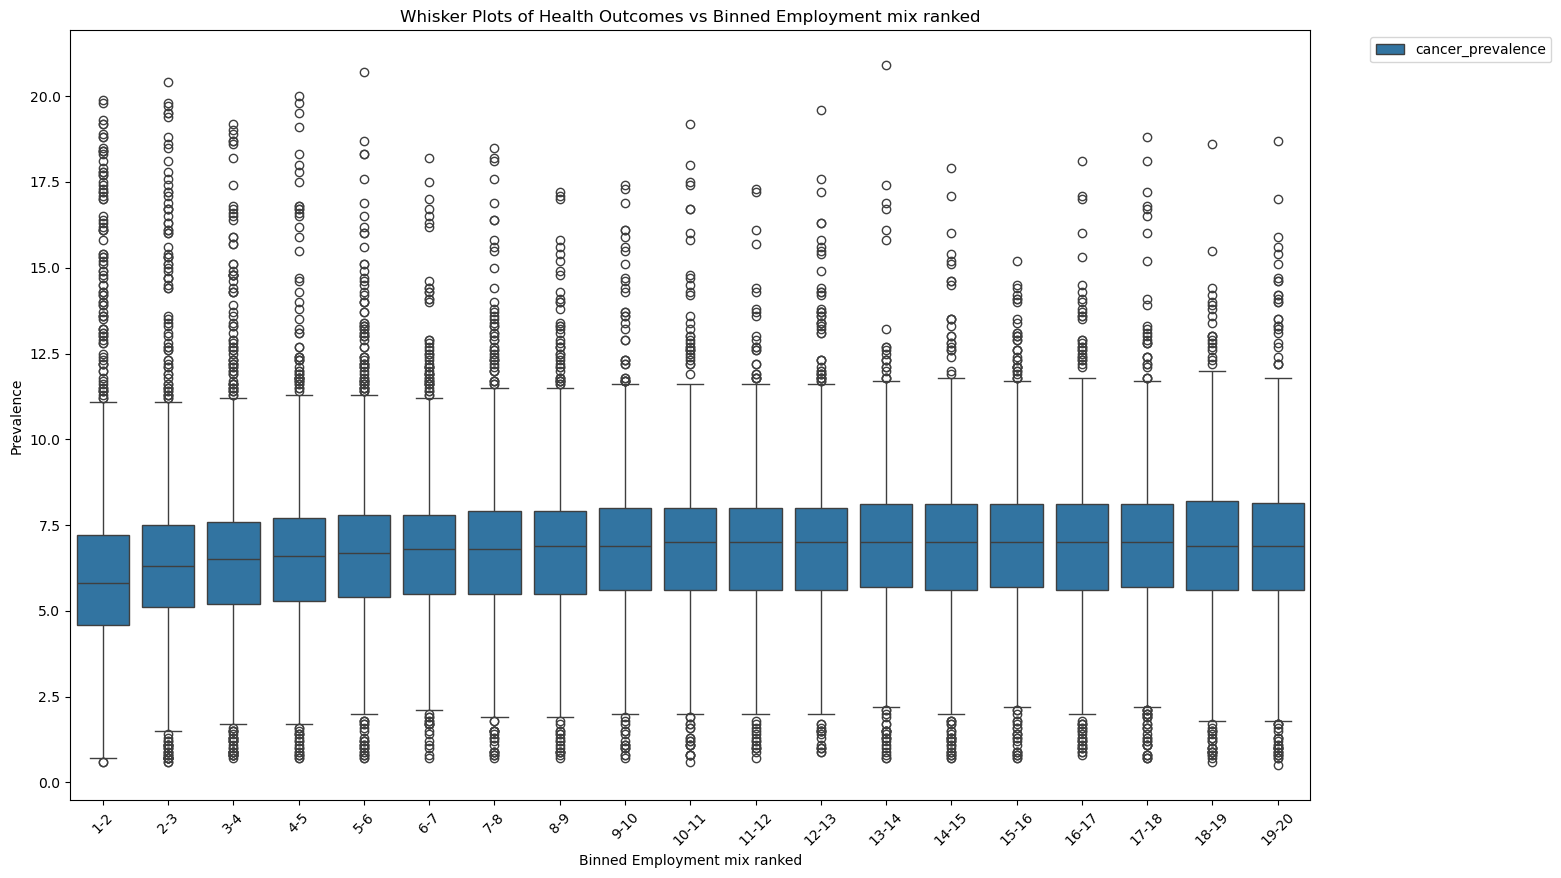

current_asthma_prevalence


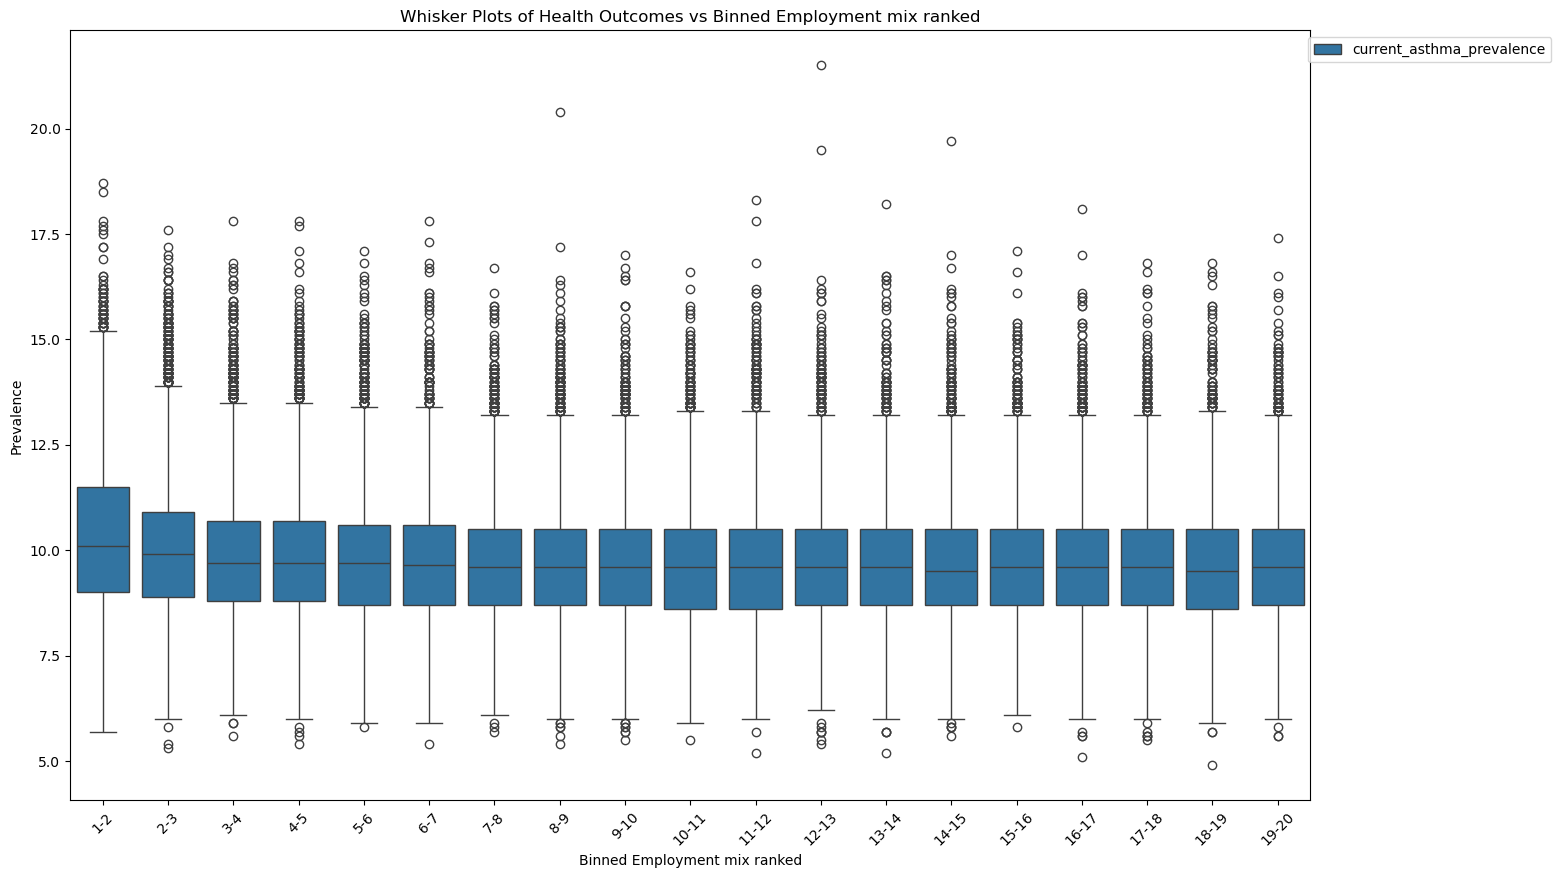

coronary_heart_disease_prevalence


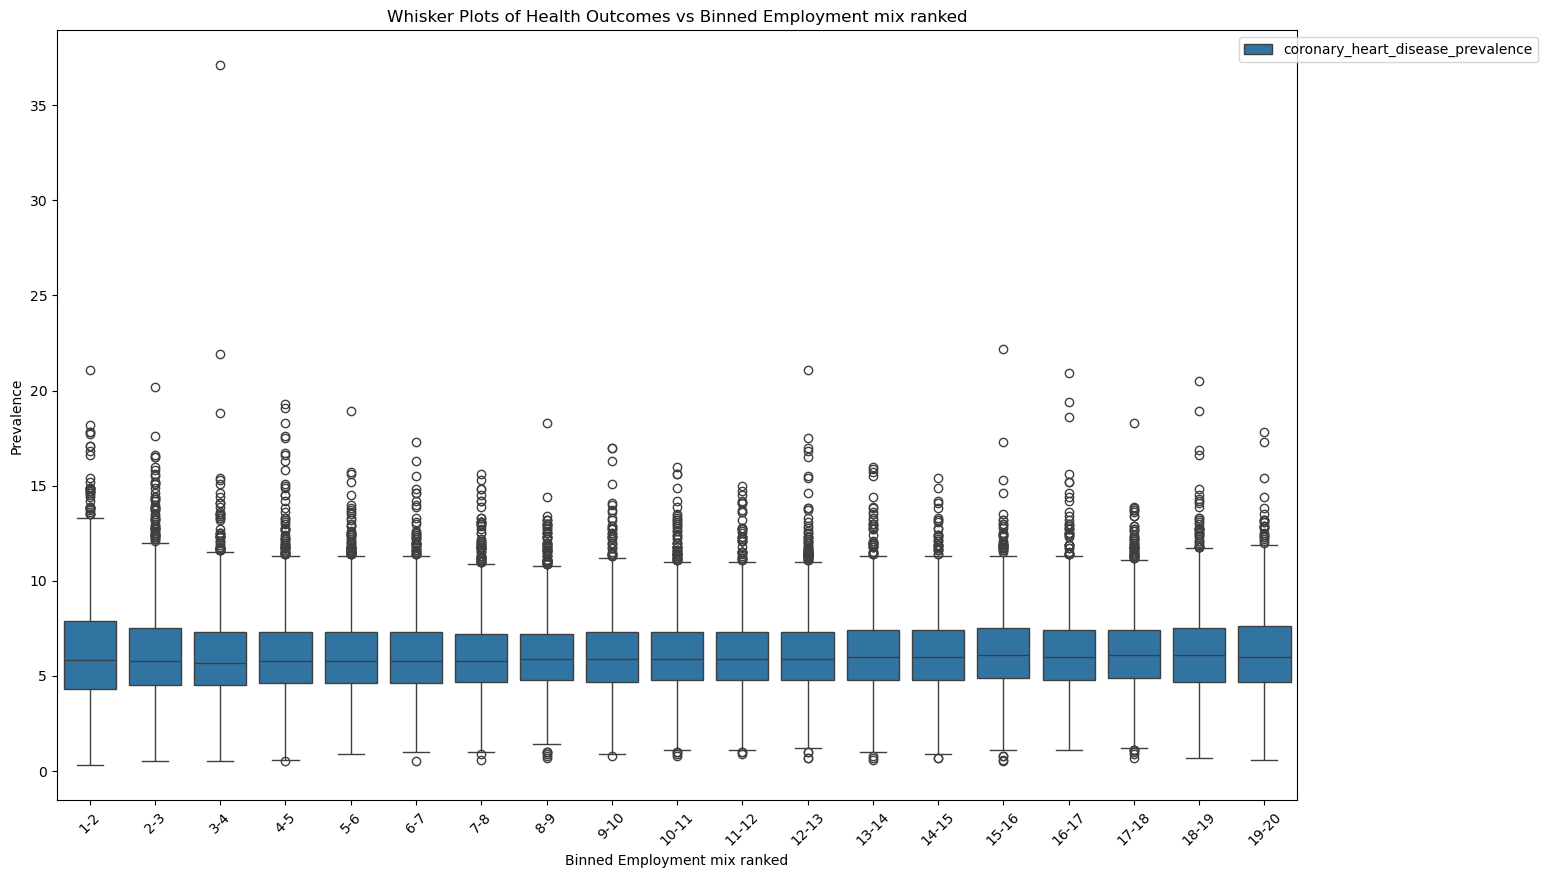

stroke_prevalence


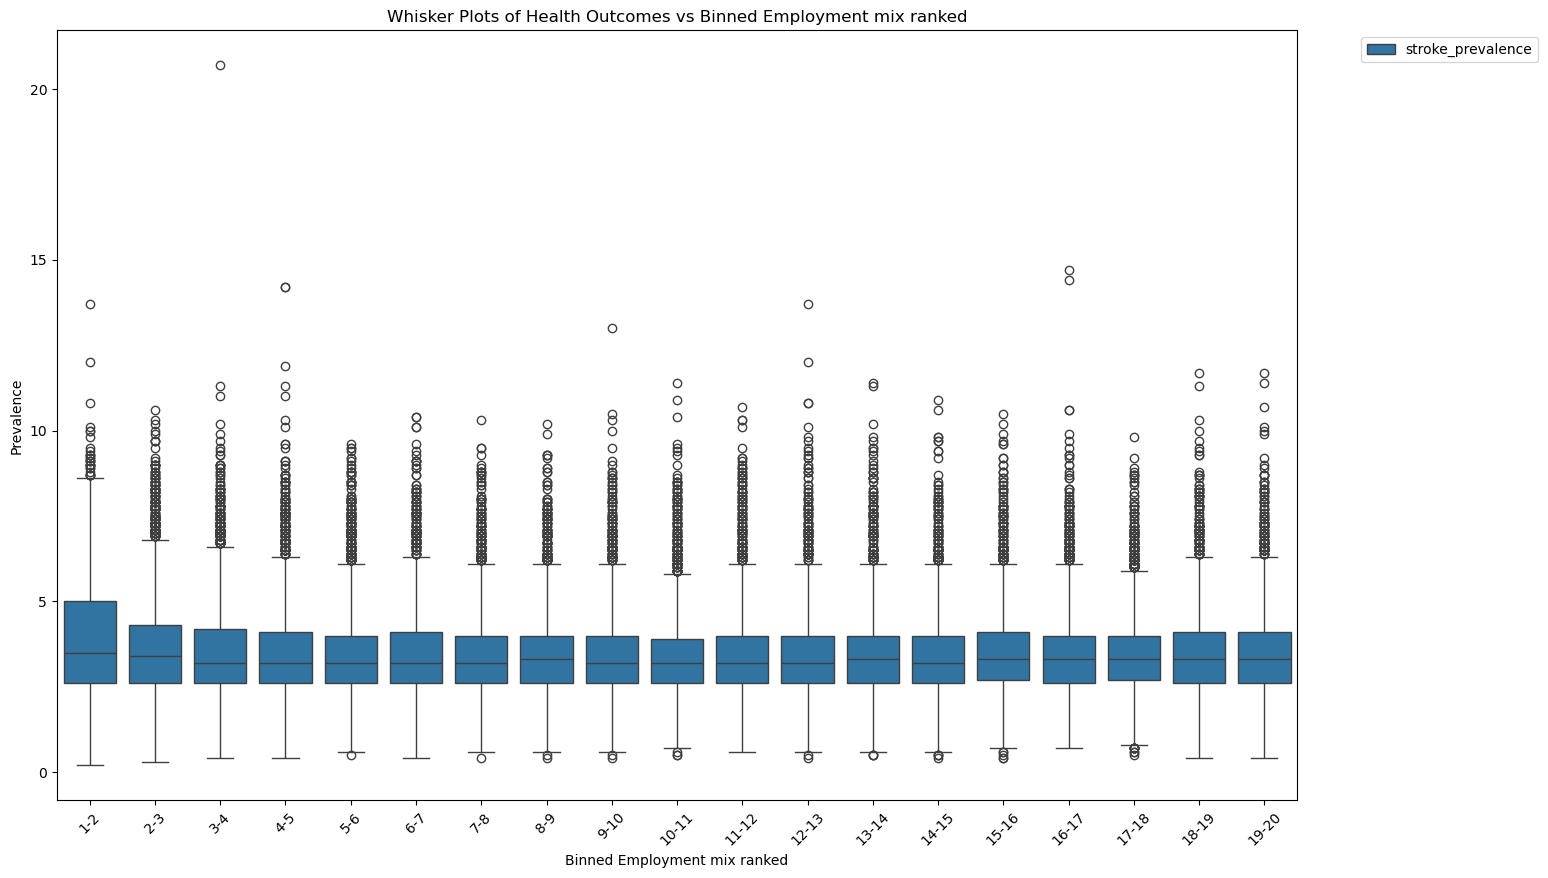

In [31]:
# Bin the `employment_mix_ranked` into intervals from 1-2, 2-3, ..., up to 20
bins = [i for i in range(1, 21)]  # Create bins from 1 to 21
bin_labels = [f"{i}-{i+1}" for i in range(1, 20)]  # Create labels like 1-2, 2-3, ..., 19-20

for i in health_outcomes_columns:
    print(i)
   
    df['employment_mix_bin'] = pd.cut(df['employment_mix_ranked'], bins=bins, labels=bin_labels, right=False)

    # Reshape the data into a long format to plot all health outcomes together
    df_long = df.melt(id_vars=["employment_mix_bin"], value_vars= i, 
                  var_name="health_outcome", value_name="prevalence")

# Plot the whisker plots for health outcomes across binned data
    plt.figure(figsize=(16, 10))
    sns.boxplot(x="employment_mix_bin", y="prevalence", hue="health_outcome", data=df_long)

# Improve readability
    plt.xticks(rotation=45)  # Rotate x-axis labels for clarity
    plt.title("Whisker Plots of Health Outcomes vs Binned Employment mix ranked")
    plt.xlabel("Binned Employment mix ranked")
    plt.ylabel("Prevalence")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()


### Box plots for employment/housing mixing

obesity_prevalence


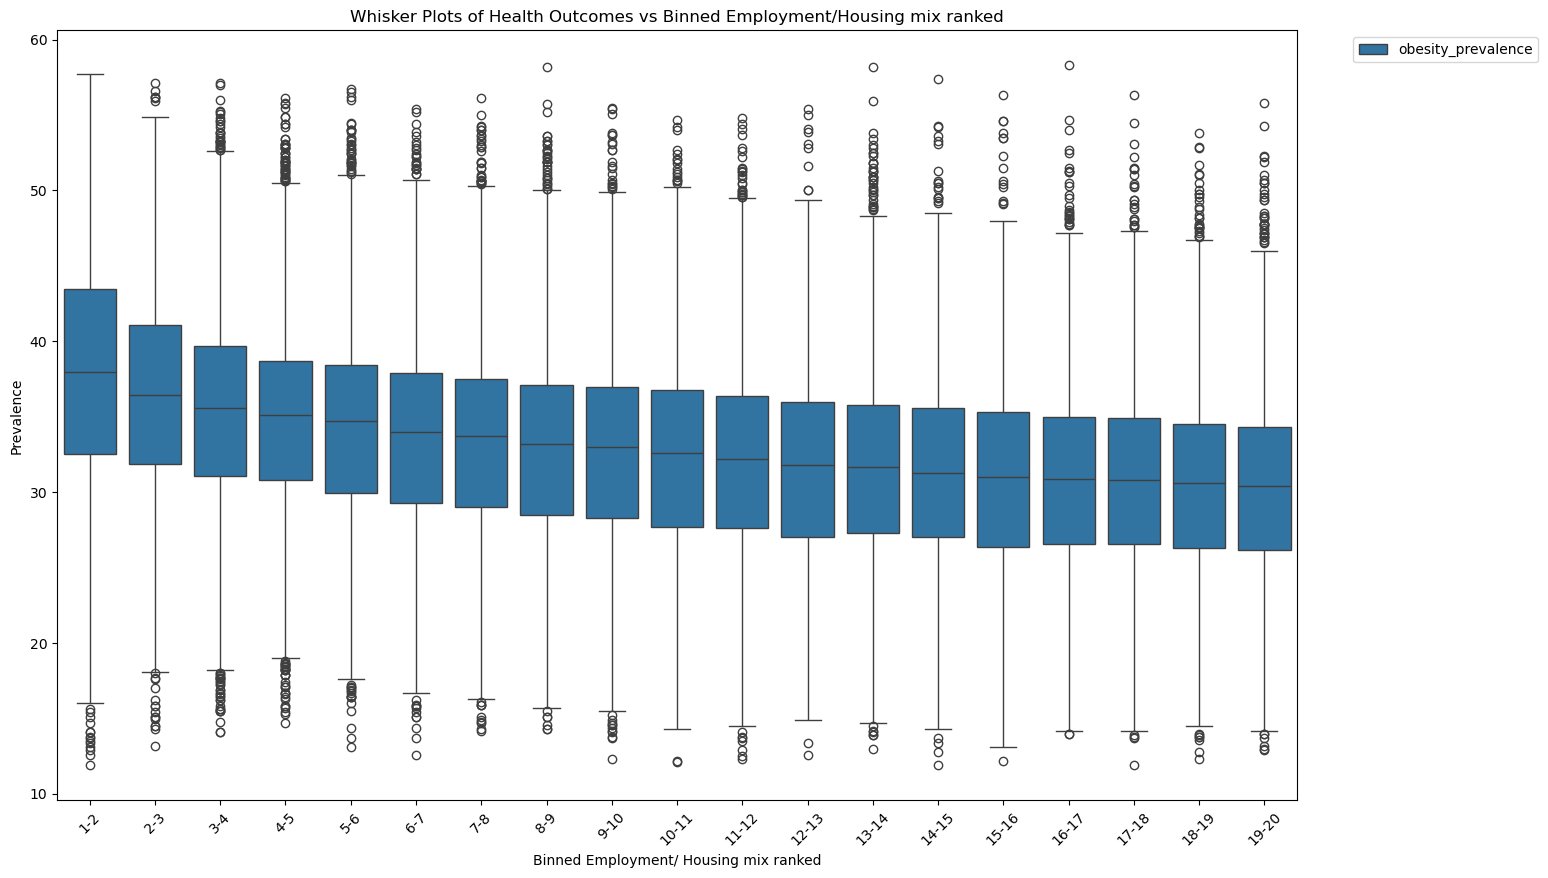

diabetes_prevalence


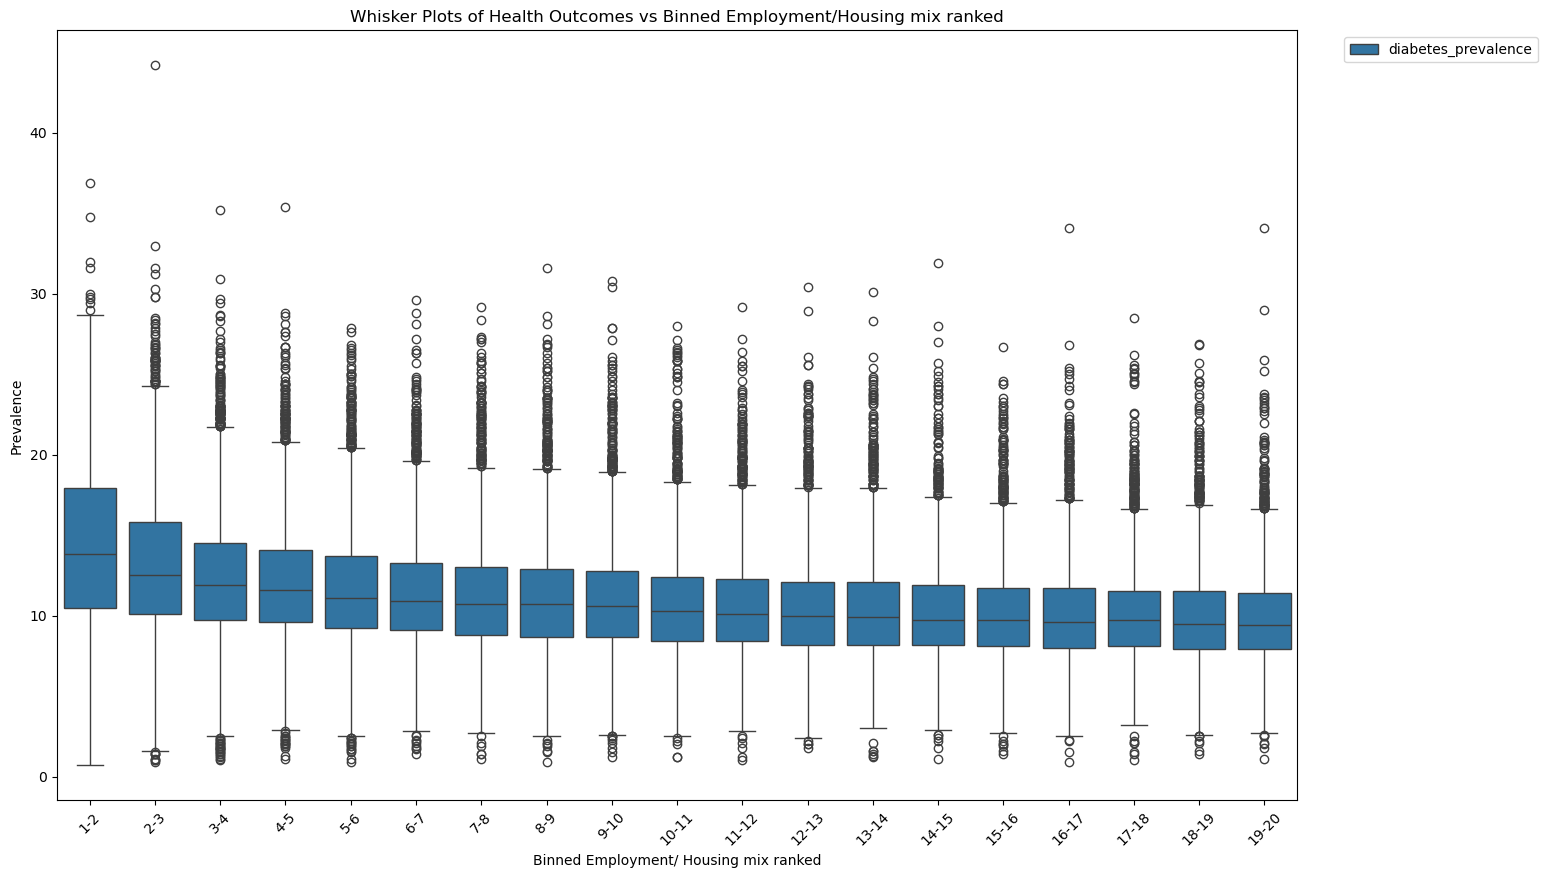

high_blood_pressure_prevalence


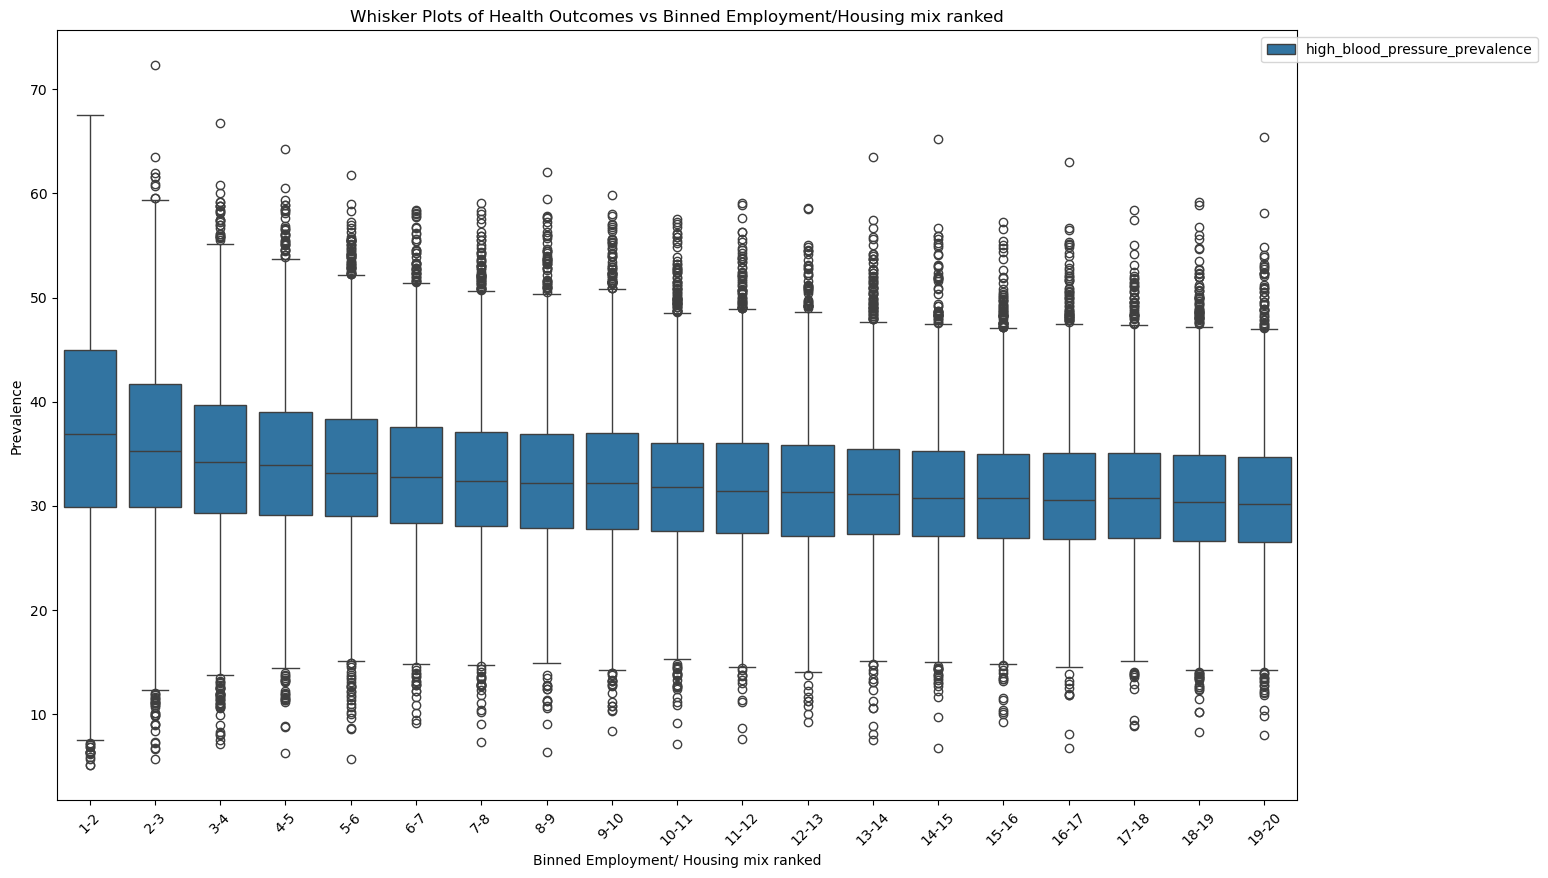

depression_prevalence


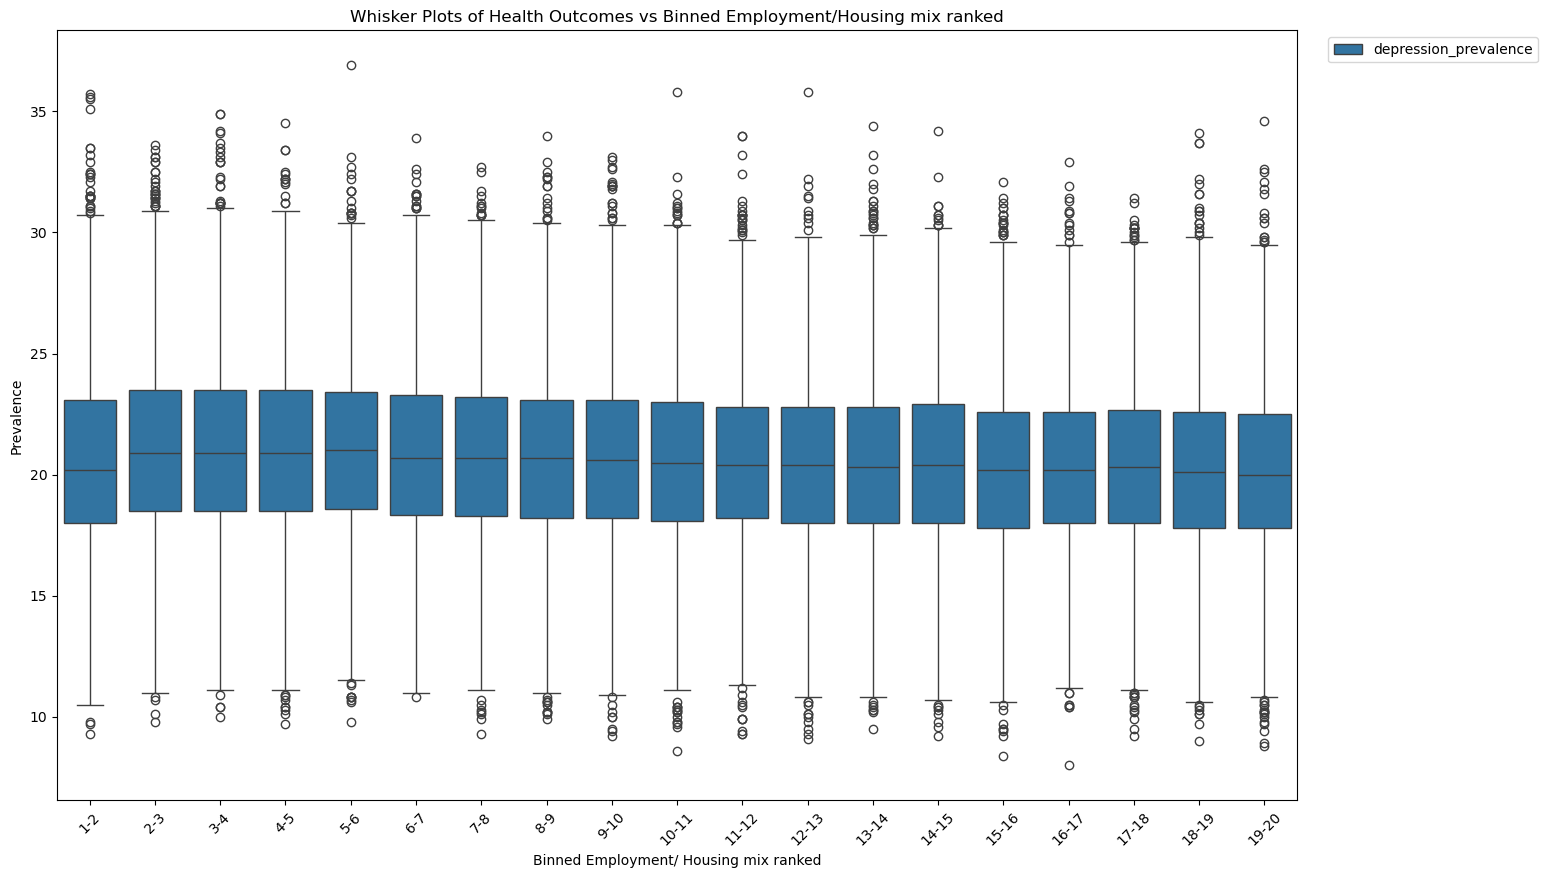

high_cholesterol_prevalence


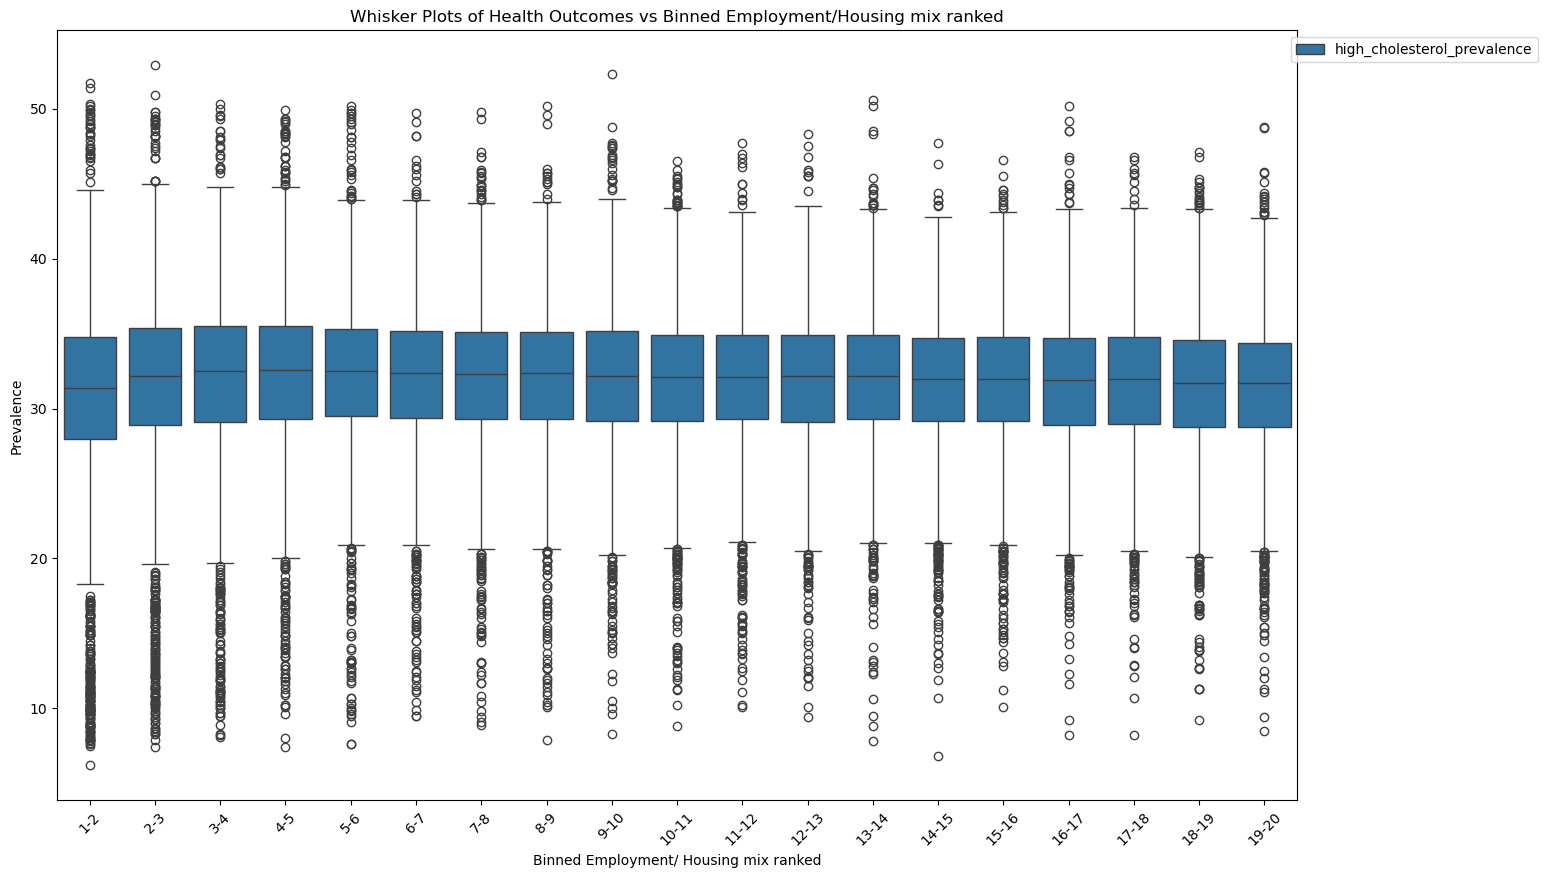

cancer_prevalence


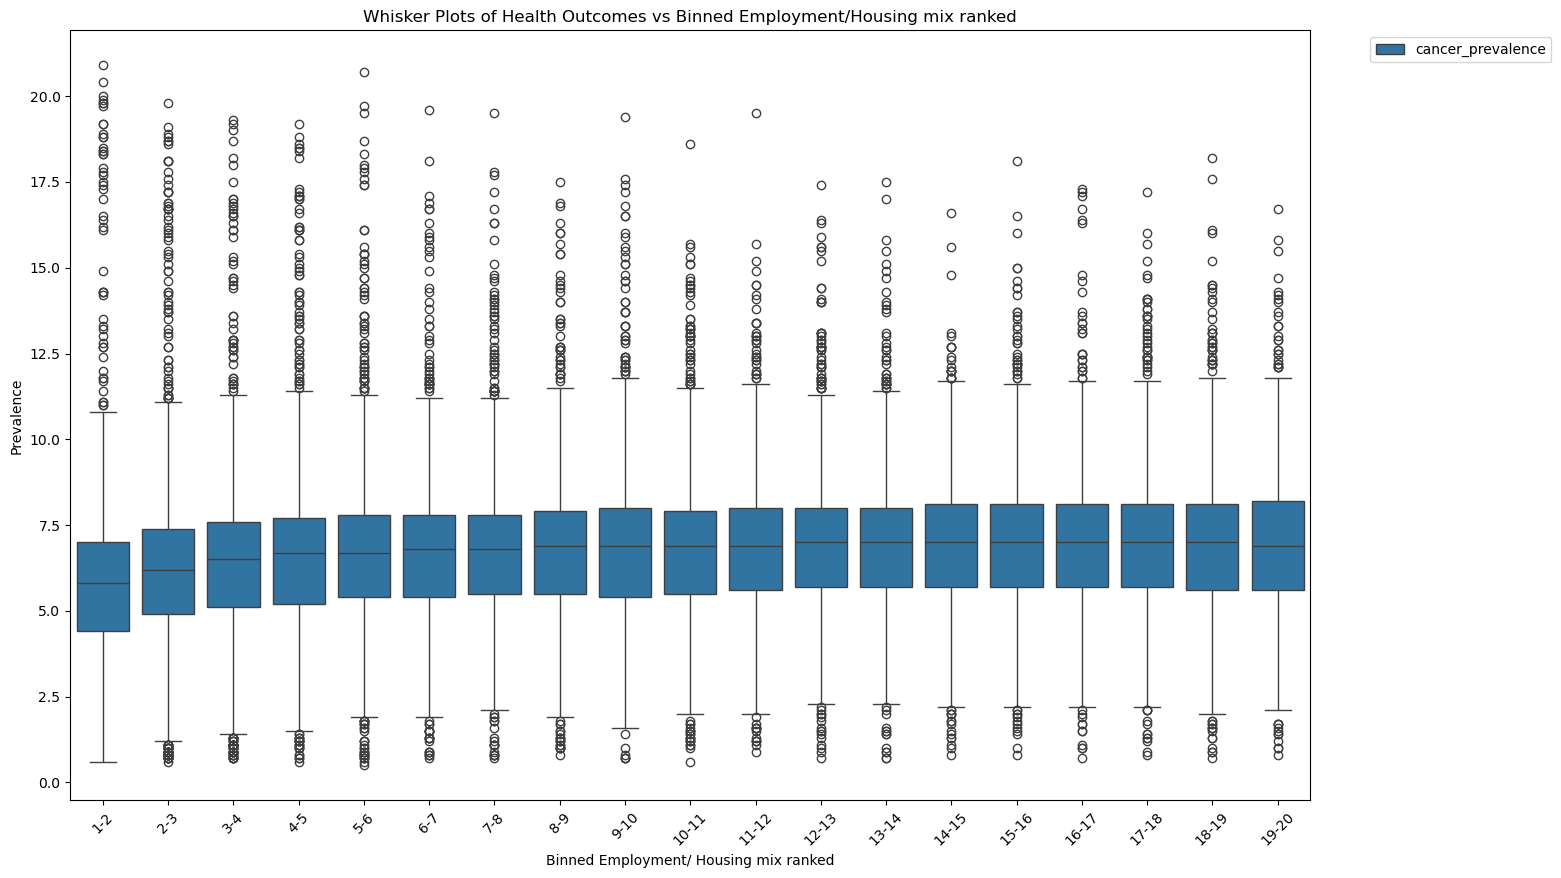

current_asthma_prevalence


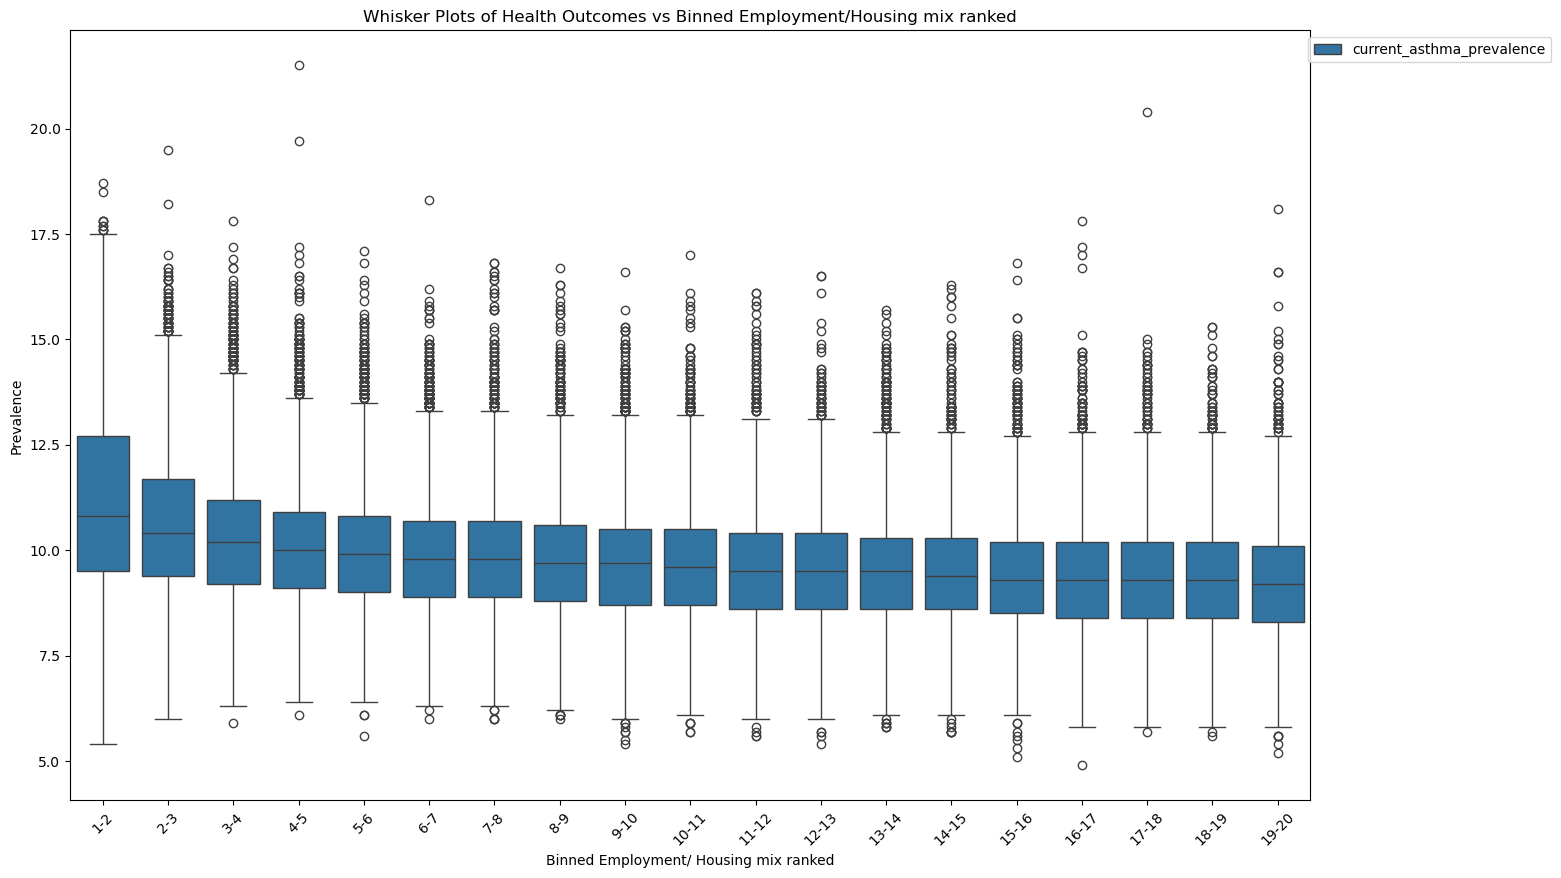

coronary_heart_disease_prevalence


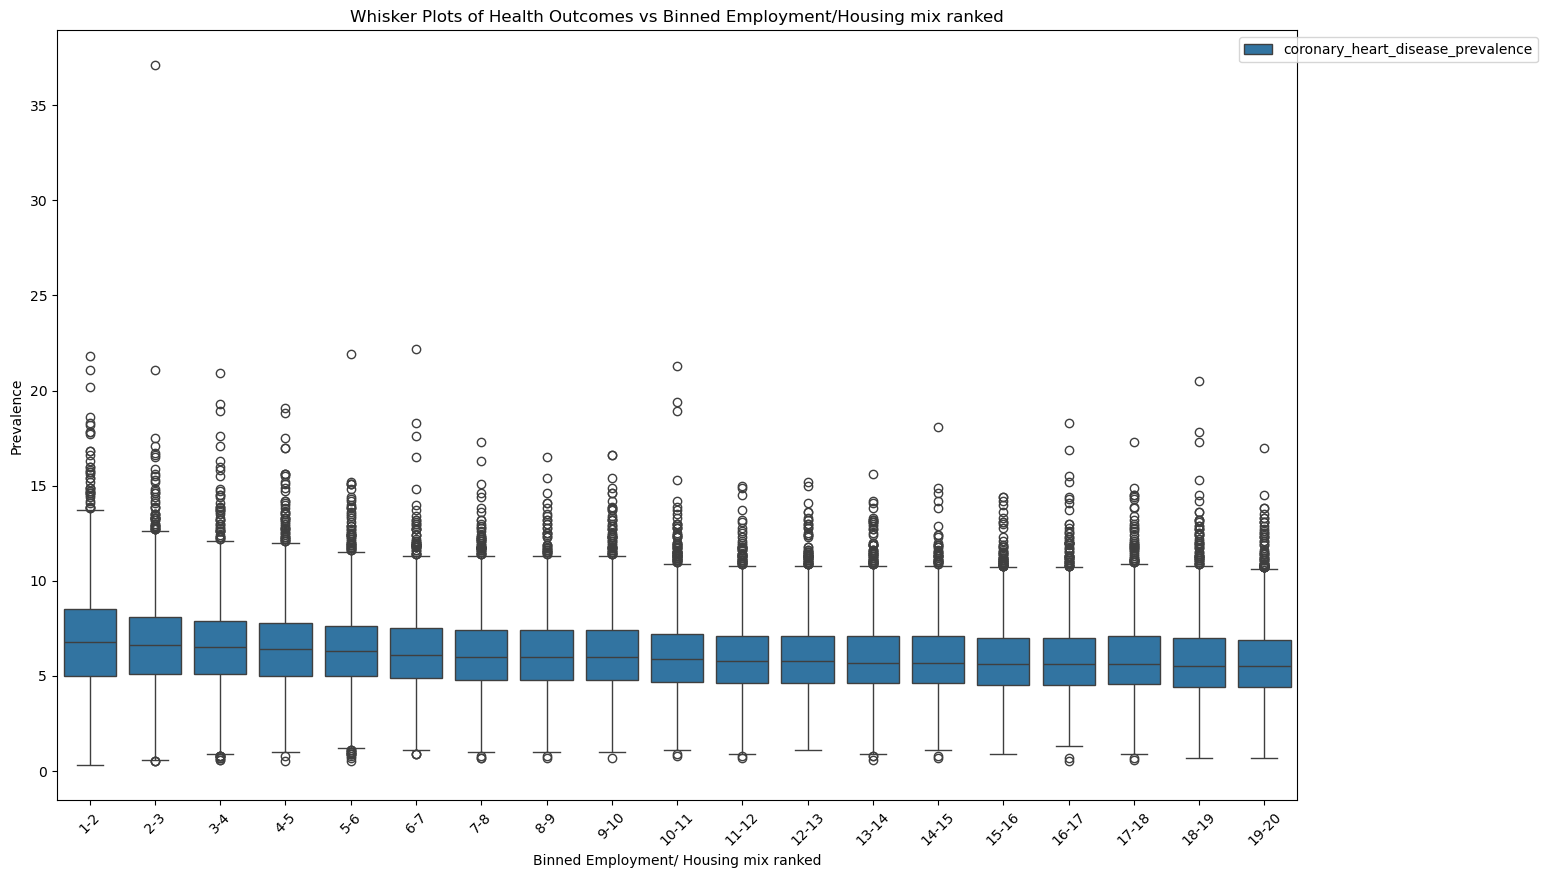

stroke_prevalence


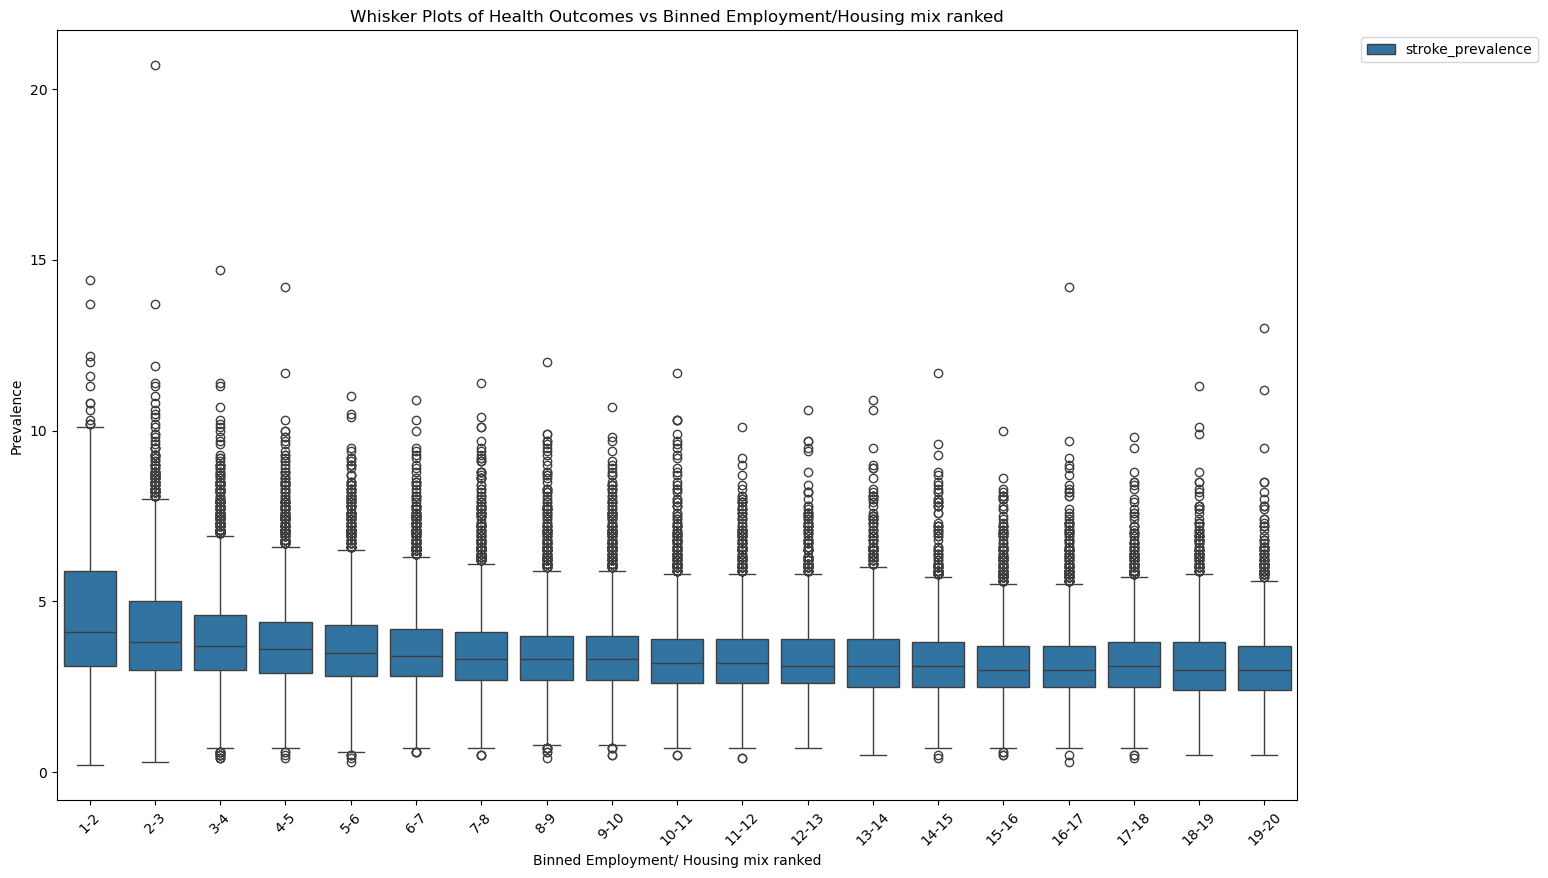

In [32]:

# Bin the `employment_residential_mix_ranked` into intervals from 1-2, 2-3, ..., up to 20
bins = [i for i in range(1, 21)]  # Create bins from 1 to 21
bin_labels = [f"{i}-{i+1}" for i in range(1, 20)]  # Create labels like 1-2, 2-3, ..., 19-20

for i in health_outcomes_columns:
    print(i)
    # Create a new column for the binned data
    df['employment_residential_mix_bin'] = pd.cut(df['employment_residential_mix_ranked'], bins=bins, labels=bin_labels, right=False)

    # Reshape the data into a long format to plot all health outcomes together
    df_long = df.melt(id_vars=["employment_residential_mix_bin"], value_vars= i, 
                  var_name="health_outcome", value_name="prevalence")

# Plot the whisker plots for health outcomes across binned data
    plt.figure(figsize=(16, 10))
    sns.boxplot(x="employment_residential_mix_bin", y="prevalence", hue="health_outcome", data=df_long)

# Improve readability
    plt.xticks(rotation=45)  # Rotate x-axis labels for clarity
    plt.title("Whisker Plots of Health Outcomes vs Binned Employment/Housing mix ranked")
    plt.xlabel("Binned Employment/ Housing mix ranked")
    plt.ylabel("Prevalence")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()


### Box plots for intersection density

obesity_prevalence


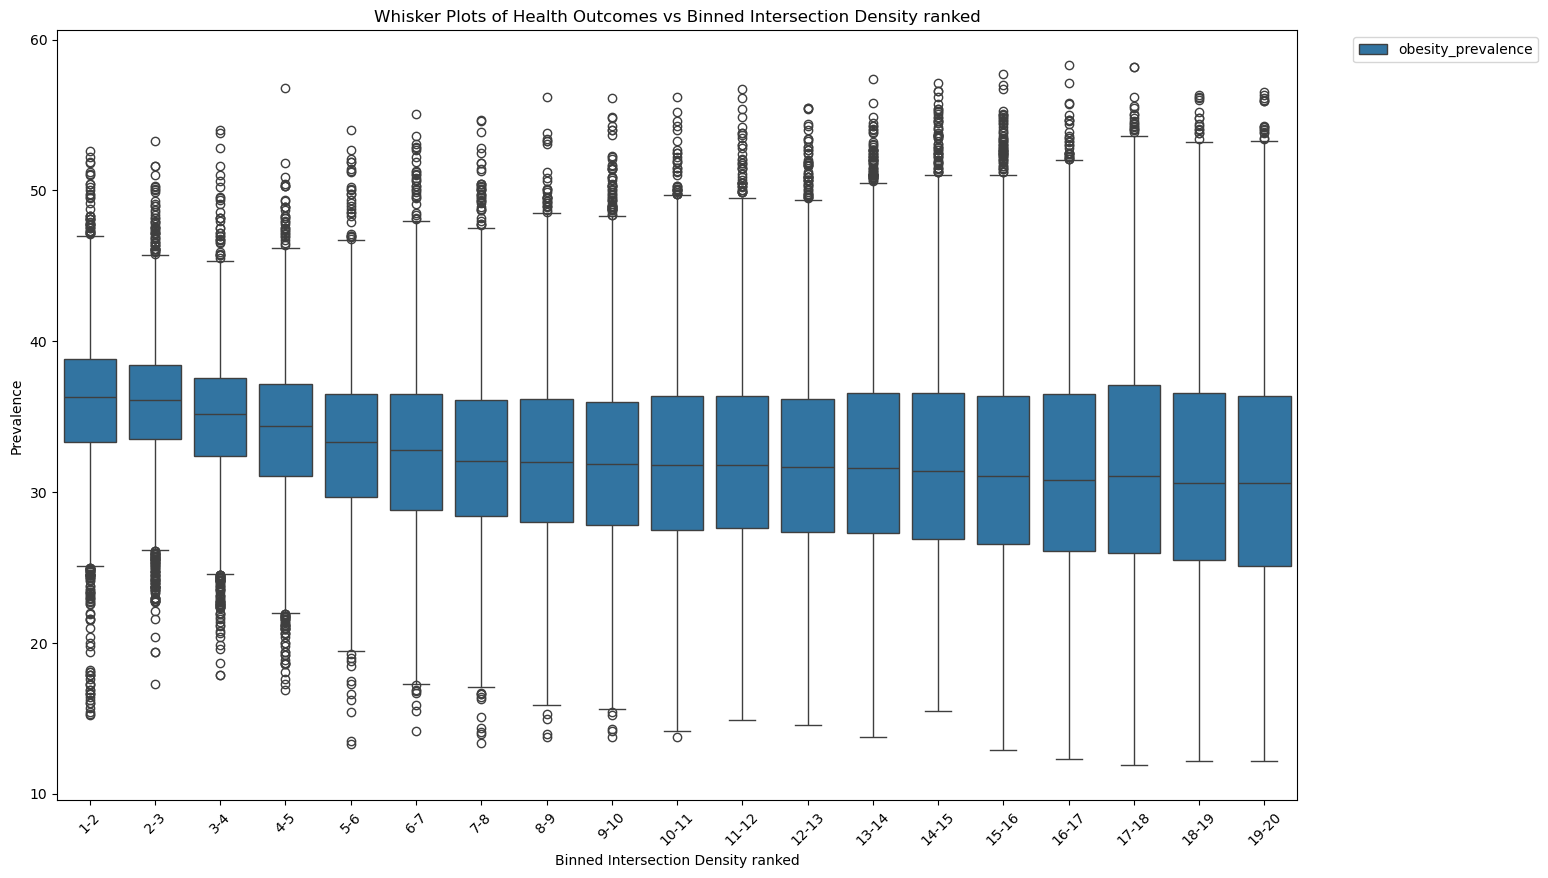

diabetes_prevalence


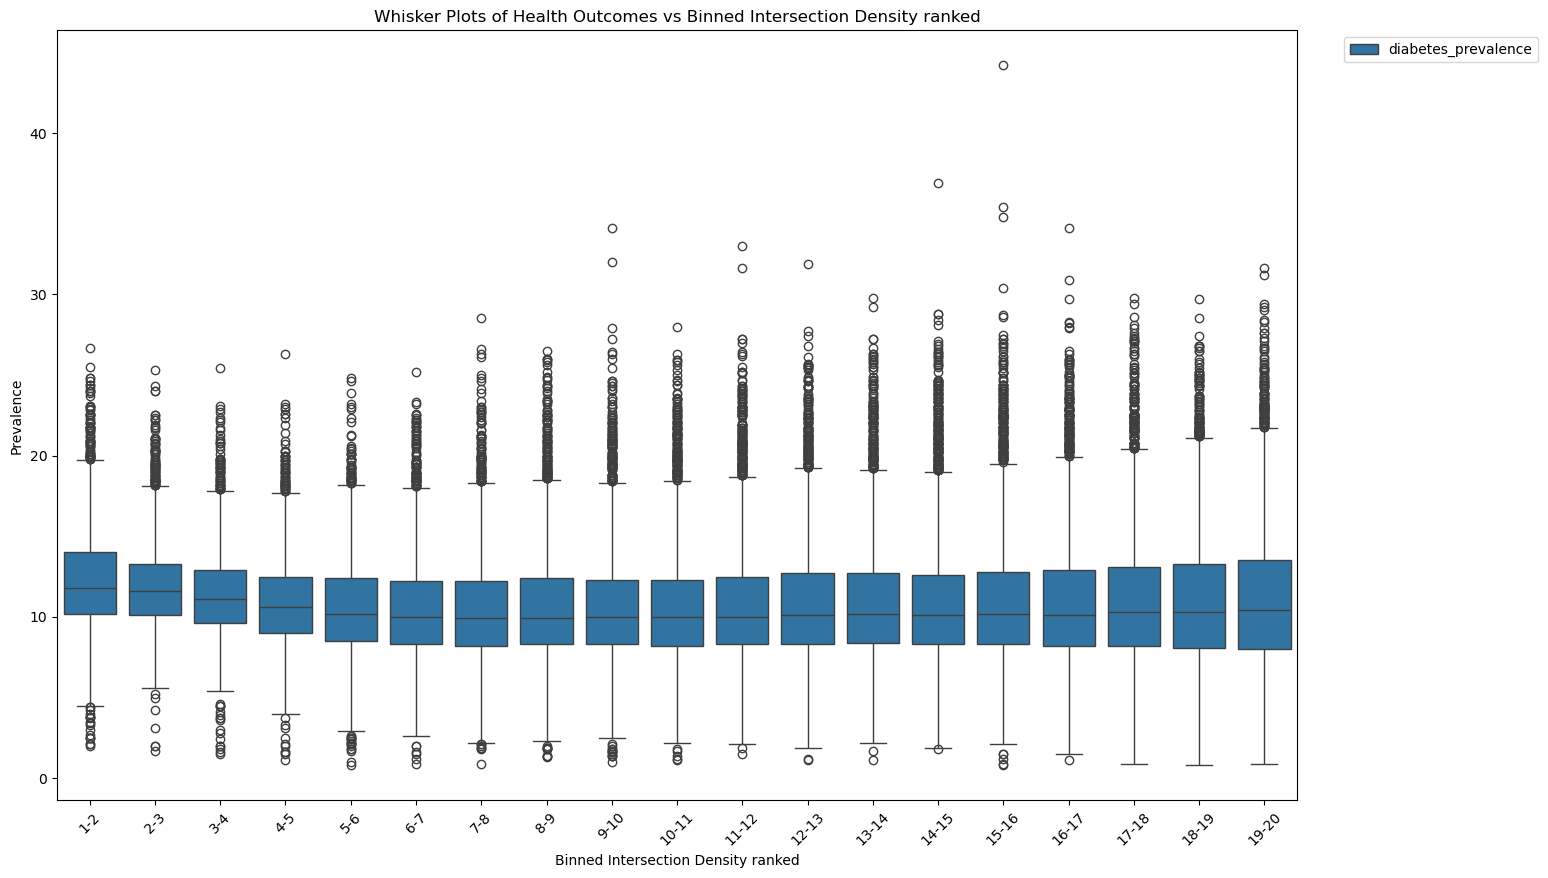

high_blood_pressure_prevalence


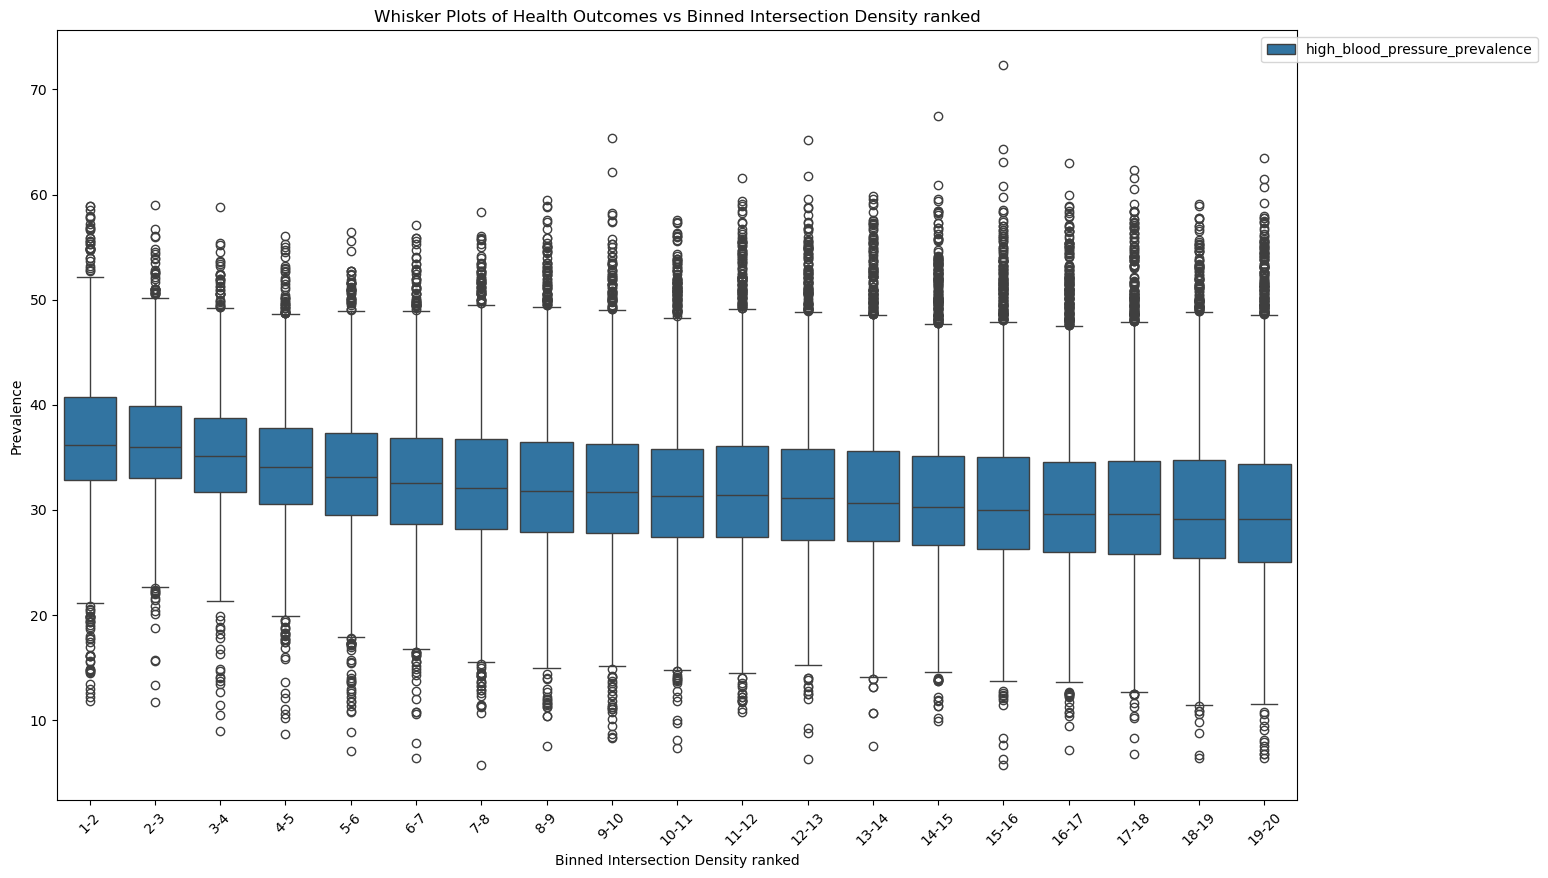

depression_prevalence


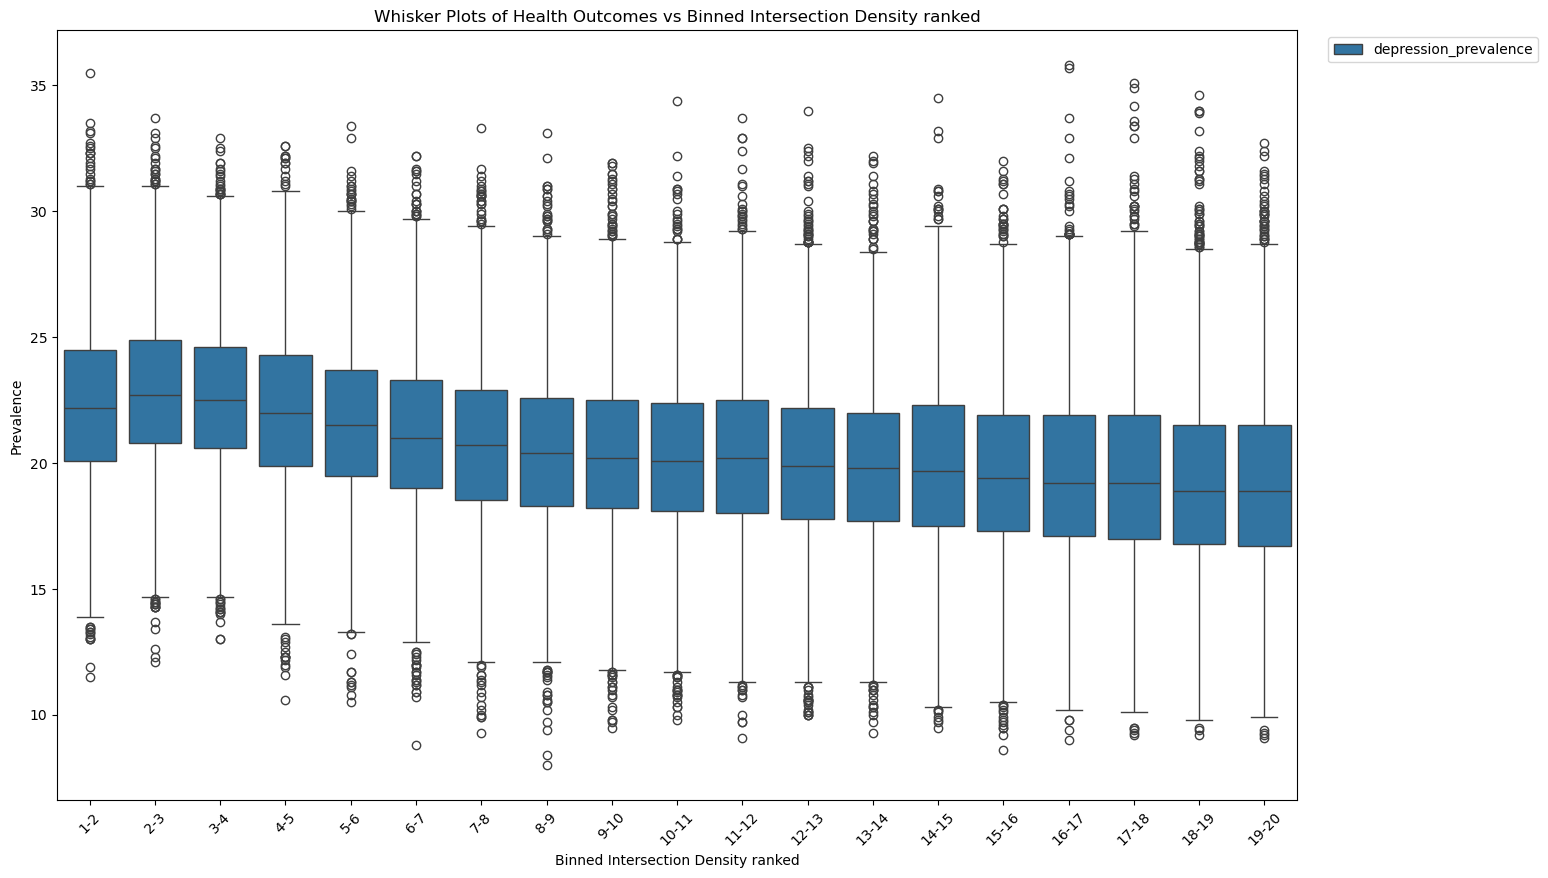

high_cholesterol_prevalence


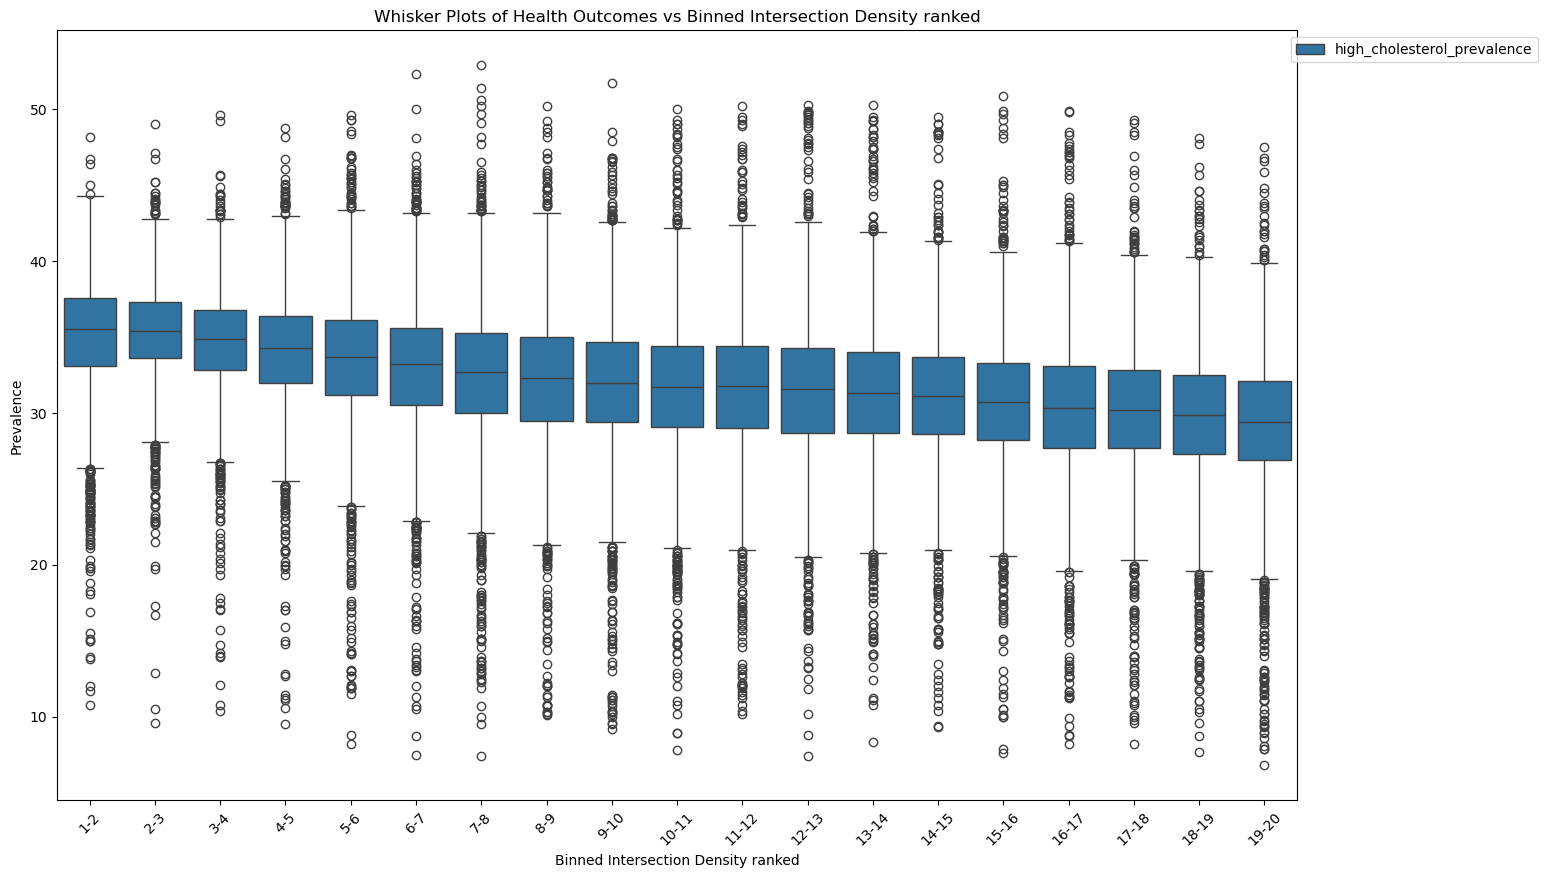

cancer_prevalence


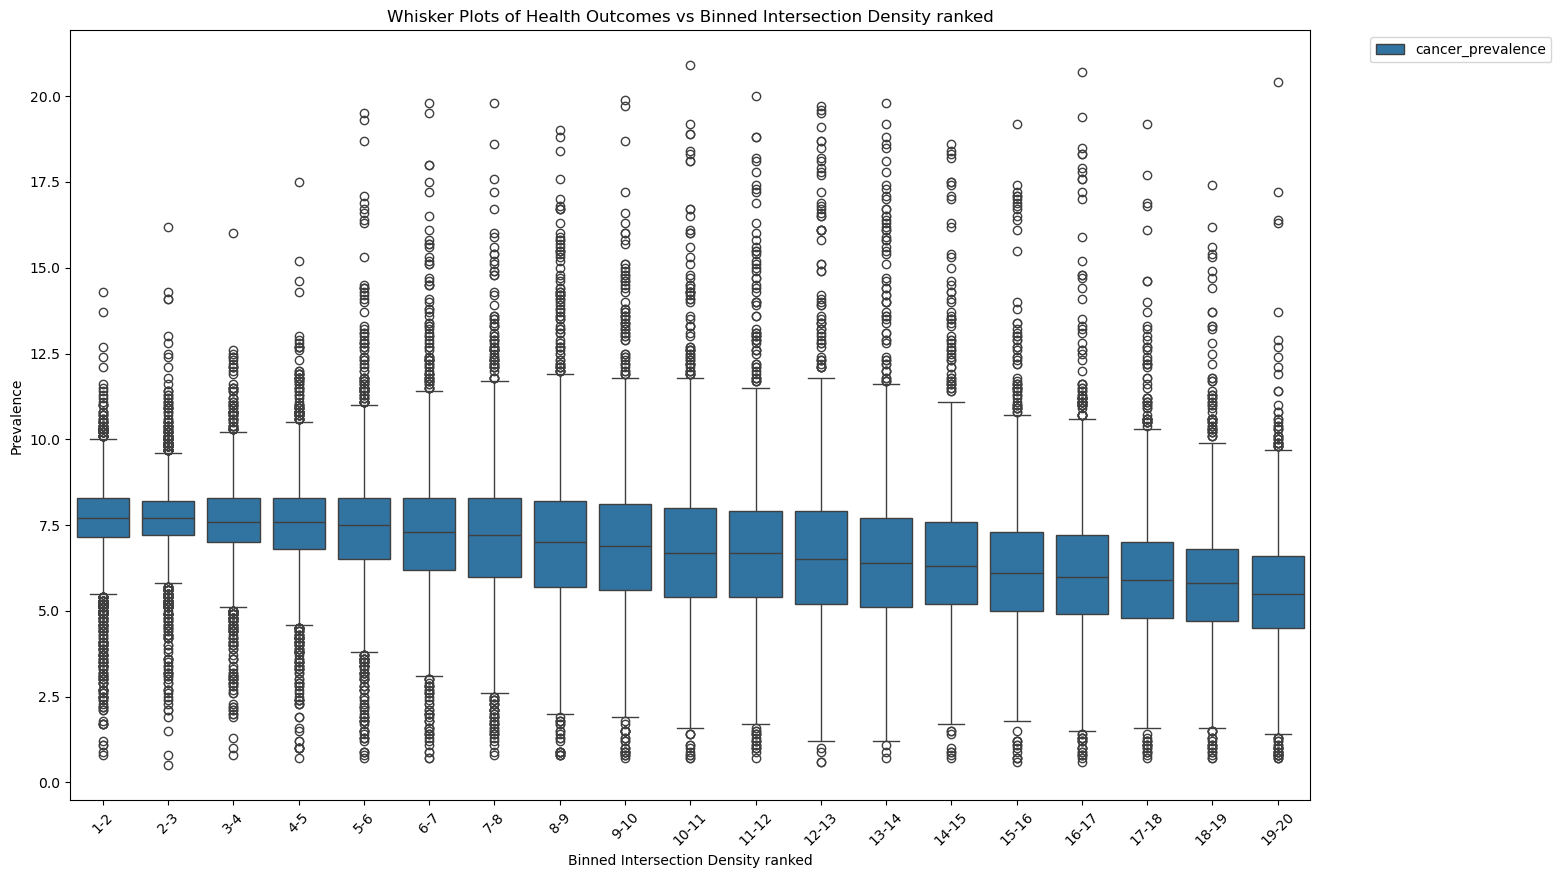

current_asthma_prevalence


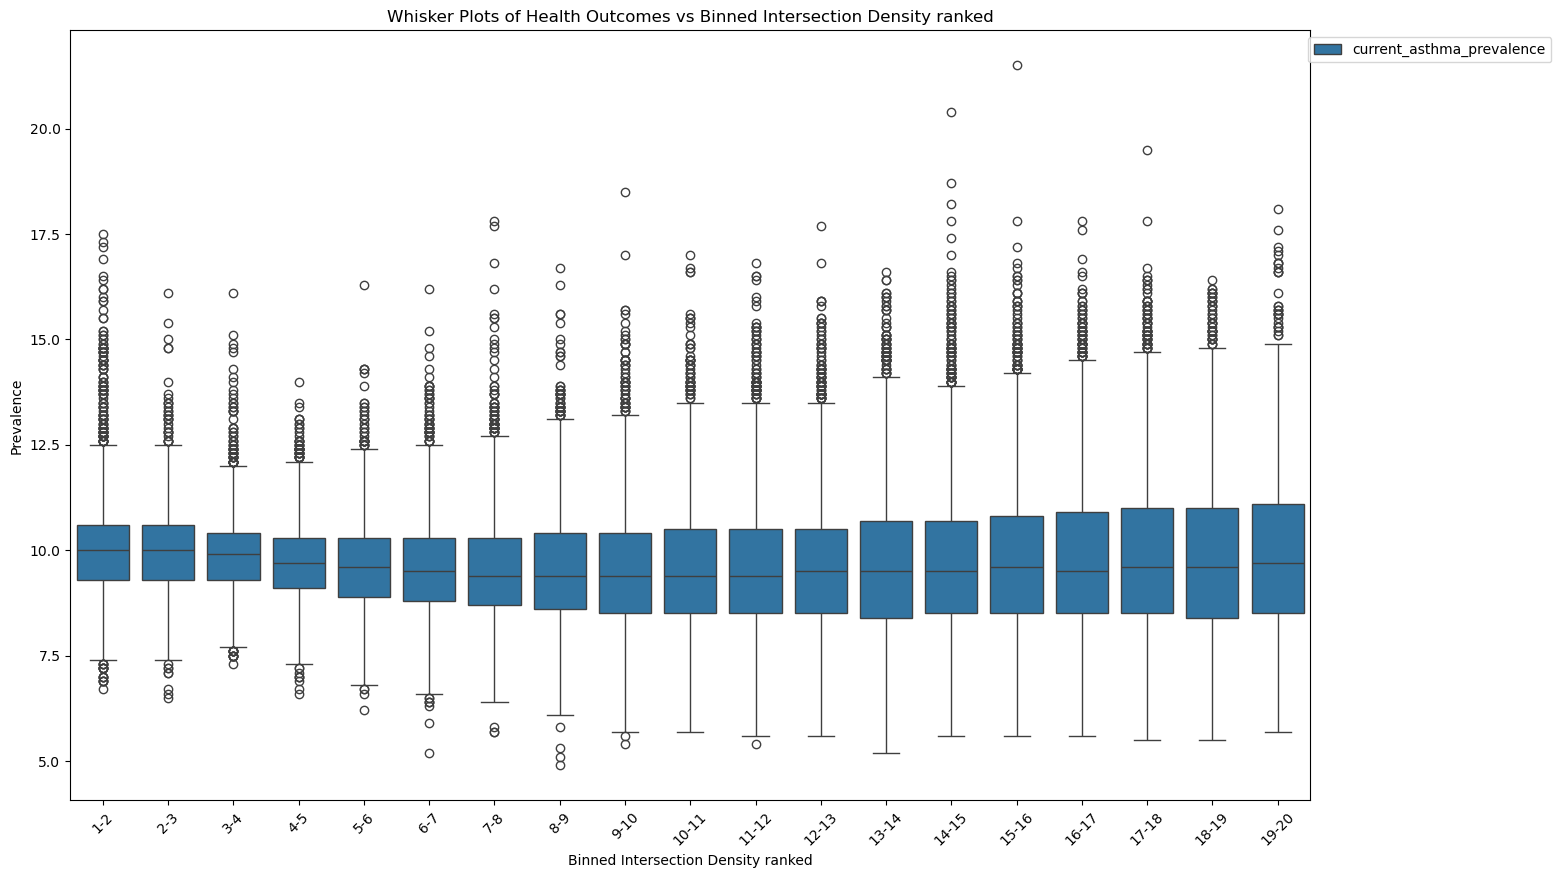

coronary_heart_disease_prevalence


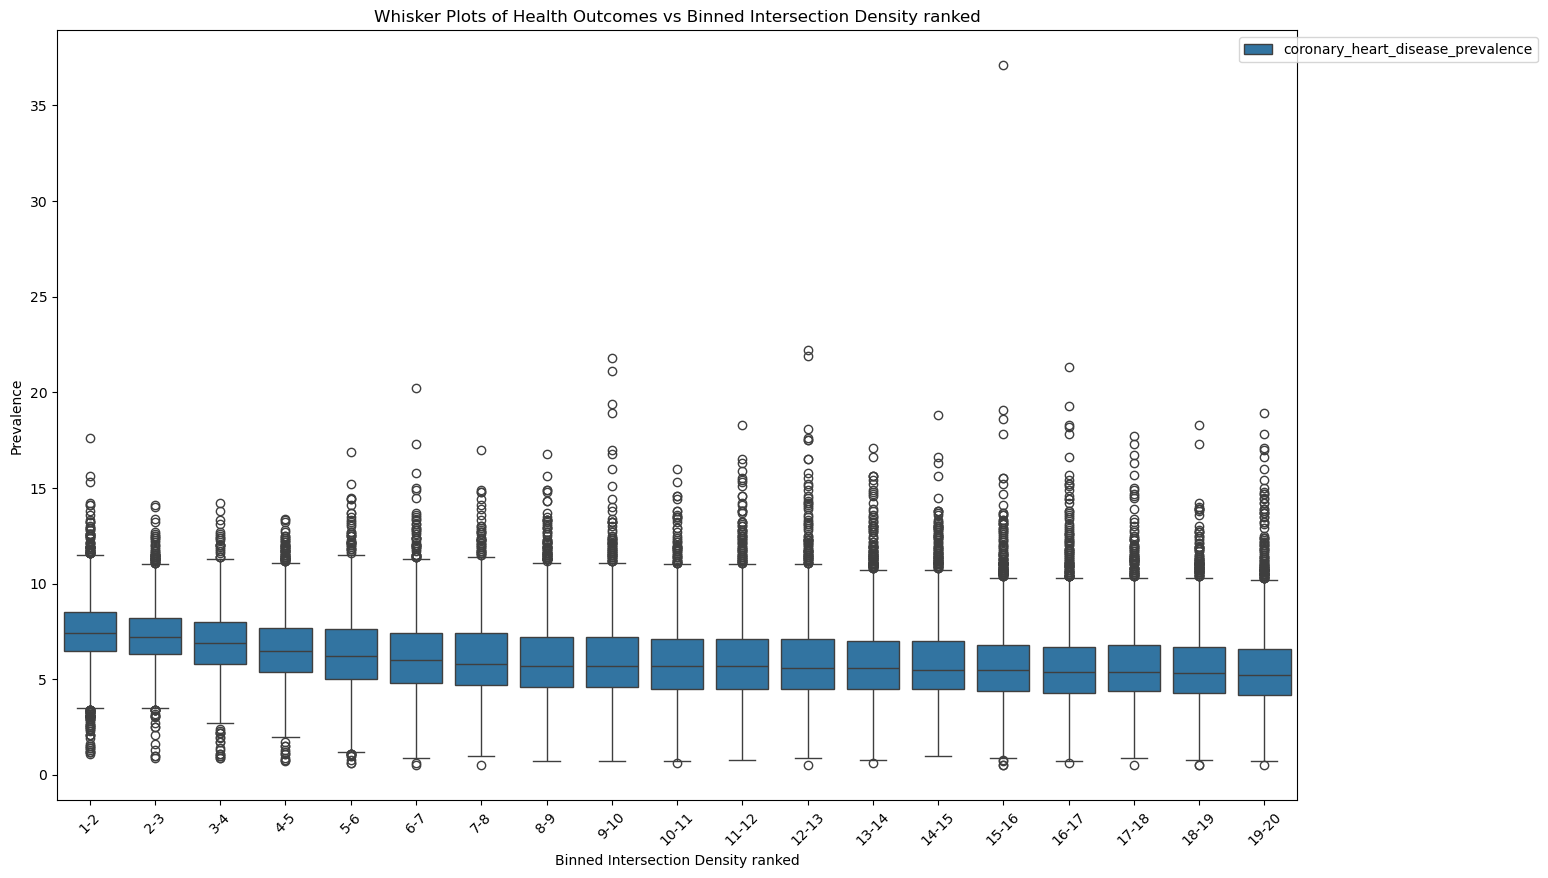

stroke_prevalence


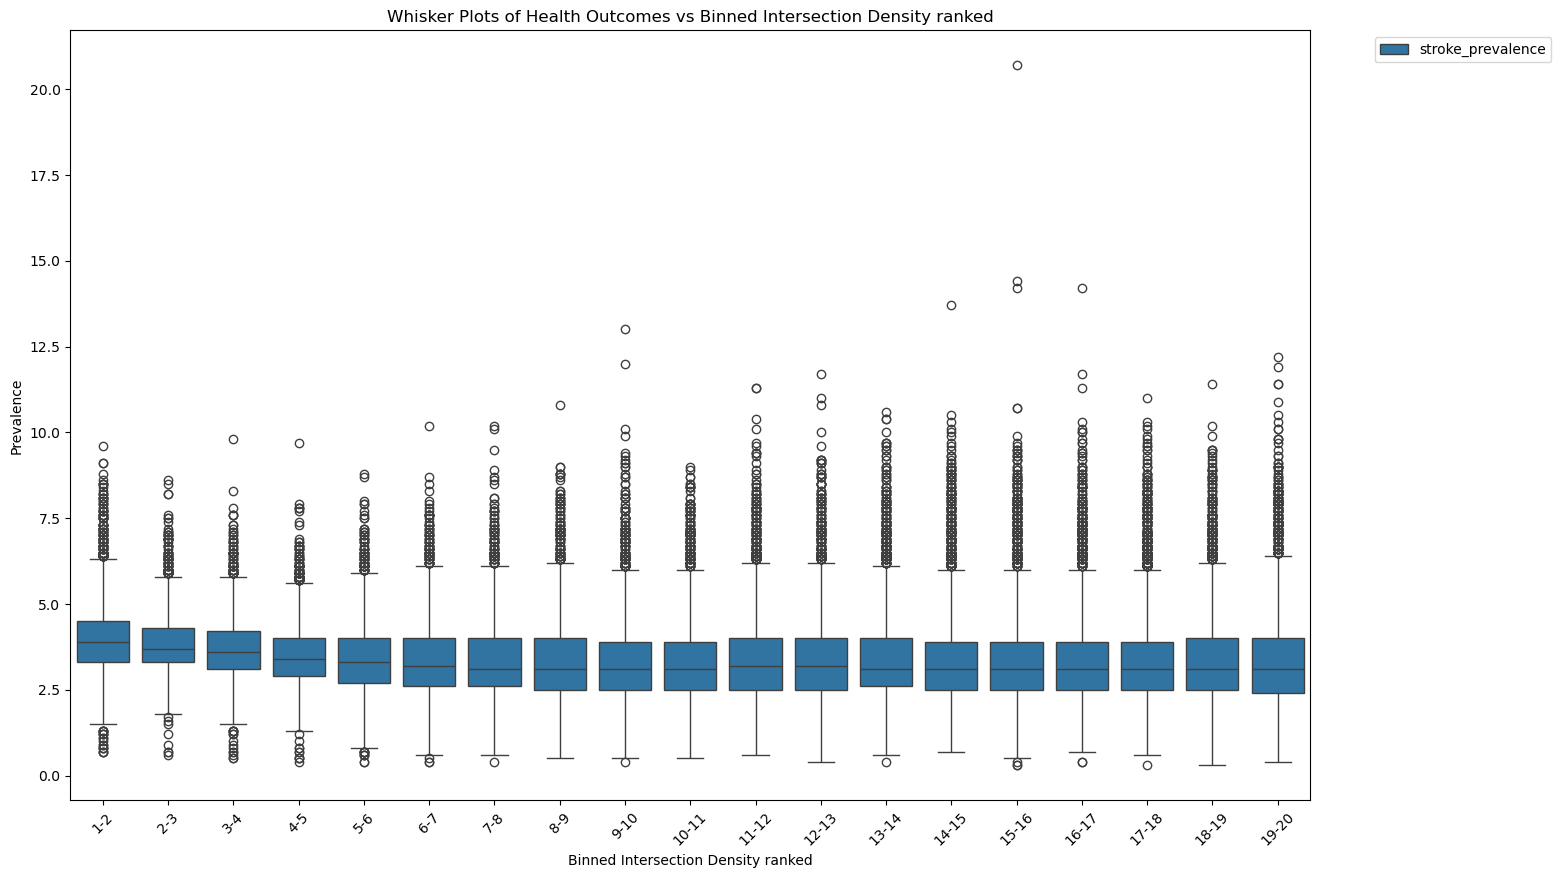

In [34]:
# Bin the intersection_density_ranked` into intervals from 1-2, 2-3, ..., up to 20
bins = [i for i in range(1, 21)]  # Create bins from 1 to 21
bin_labels = [f"{i}-{i+1}" for i in range(1, 20)]  # Create labels like 1-2, 2-3, ..., 19-20

for i in health_outcomes_columns:
    print(i)
    # Create a new column for the binned data
    df['intersection_density_ranked_bin'] = pd.cut(df['intersection_density_ranked'], bins=bins, labels=bin_labels, right=False)

    # Reshape the data into a long format to plot all health outcomes together
    df_long = df.melt(id_vars=["intersection_density_ranked_bin"], value_vars= i, 
                  var_name="health_outcome", value_name="prevalence")

# Plot the whisker plots for health outcomes across binned data
    plt.figure(figsize=(16, 10))
    sns.boxplot(x="intersection_density_ranked_bin", y="prevalence", hue="health_outcome", data=df_long)

# Improve readability
    plt.xticks(rotation=45)  # Rotate x-axis labels for clarity
    plt.title("Whisker Plots of Health Outcomes vs Binned Intersection Density ranked")
    plt.xlabel("Binned Intersection Density ranked")
    plt.ylabel("Prevalence")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()

### Box plots for Transit Accessibility

obesity_prevalence


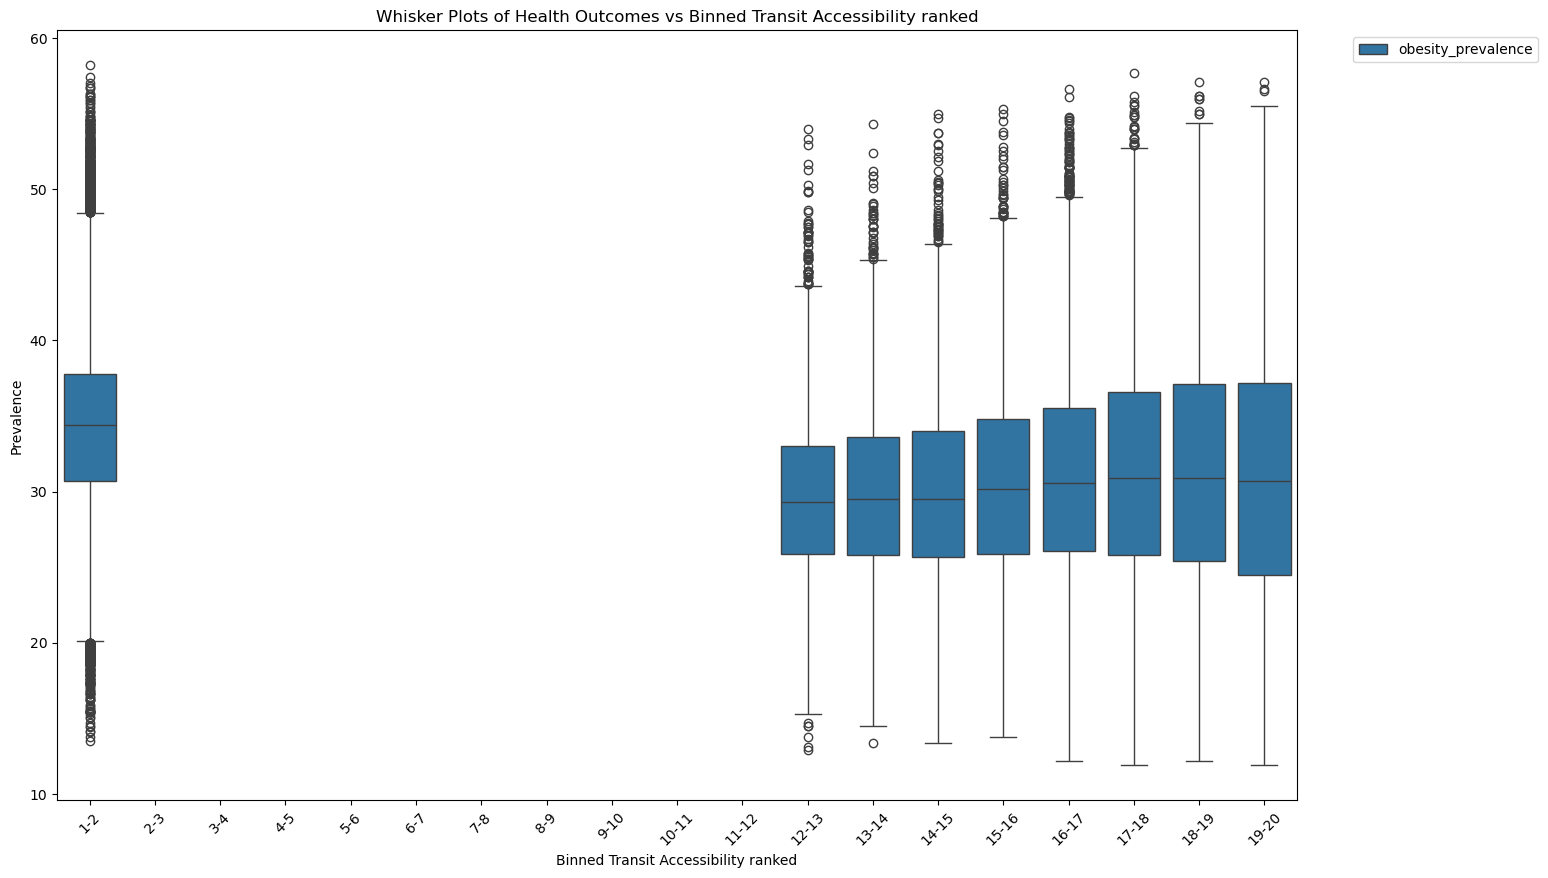

diabetes_prevalence


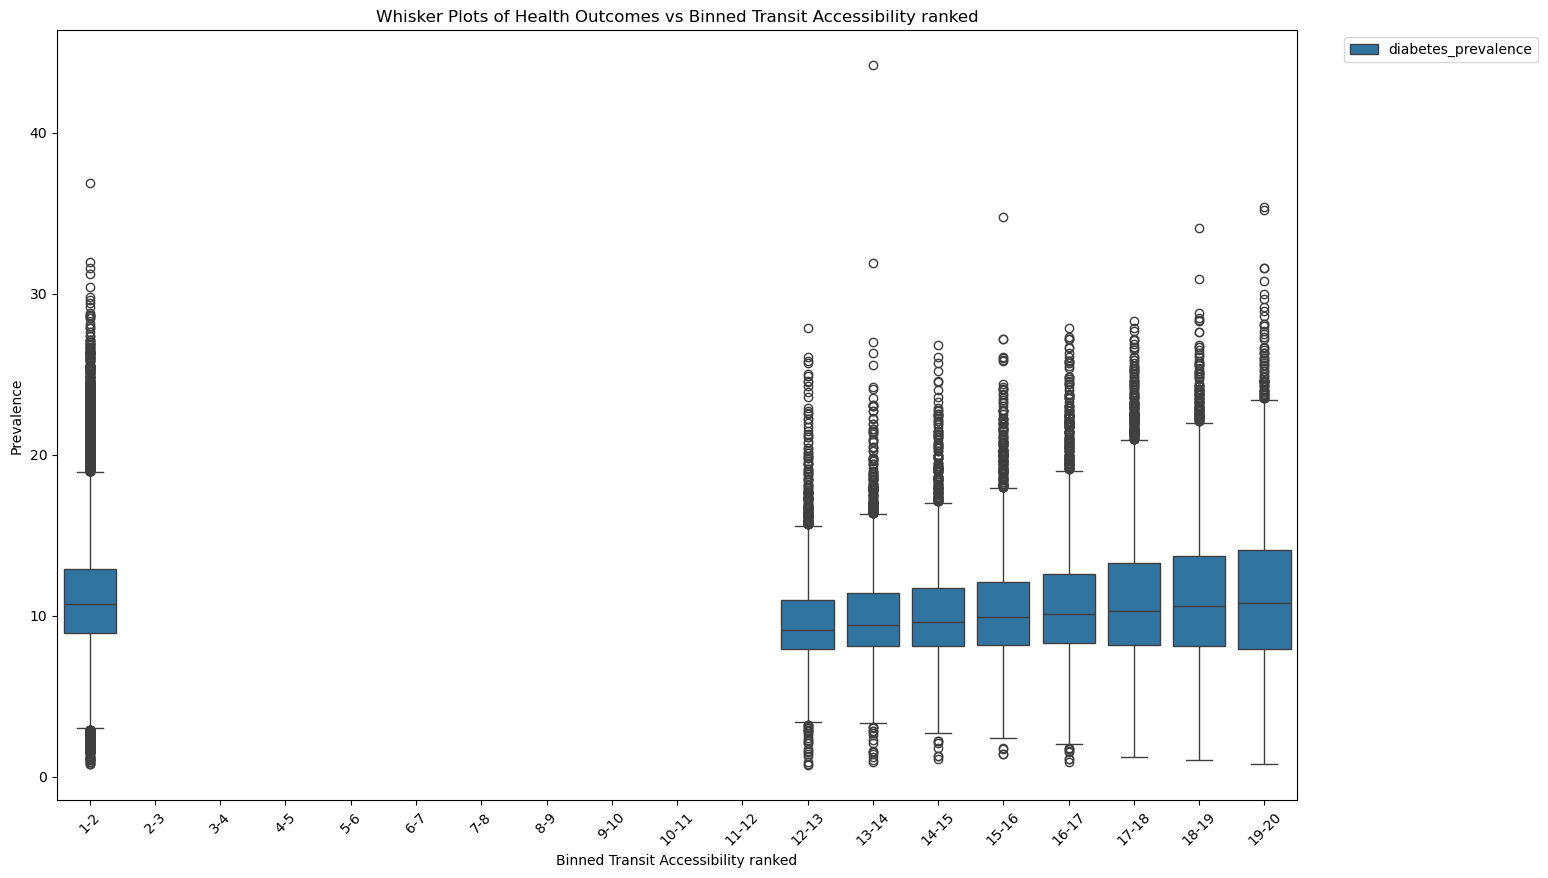

high_blood_pressure_prevalence


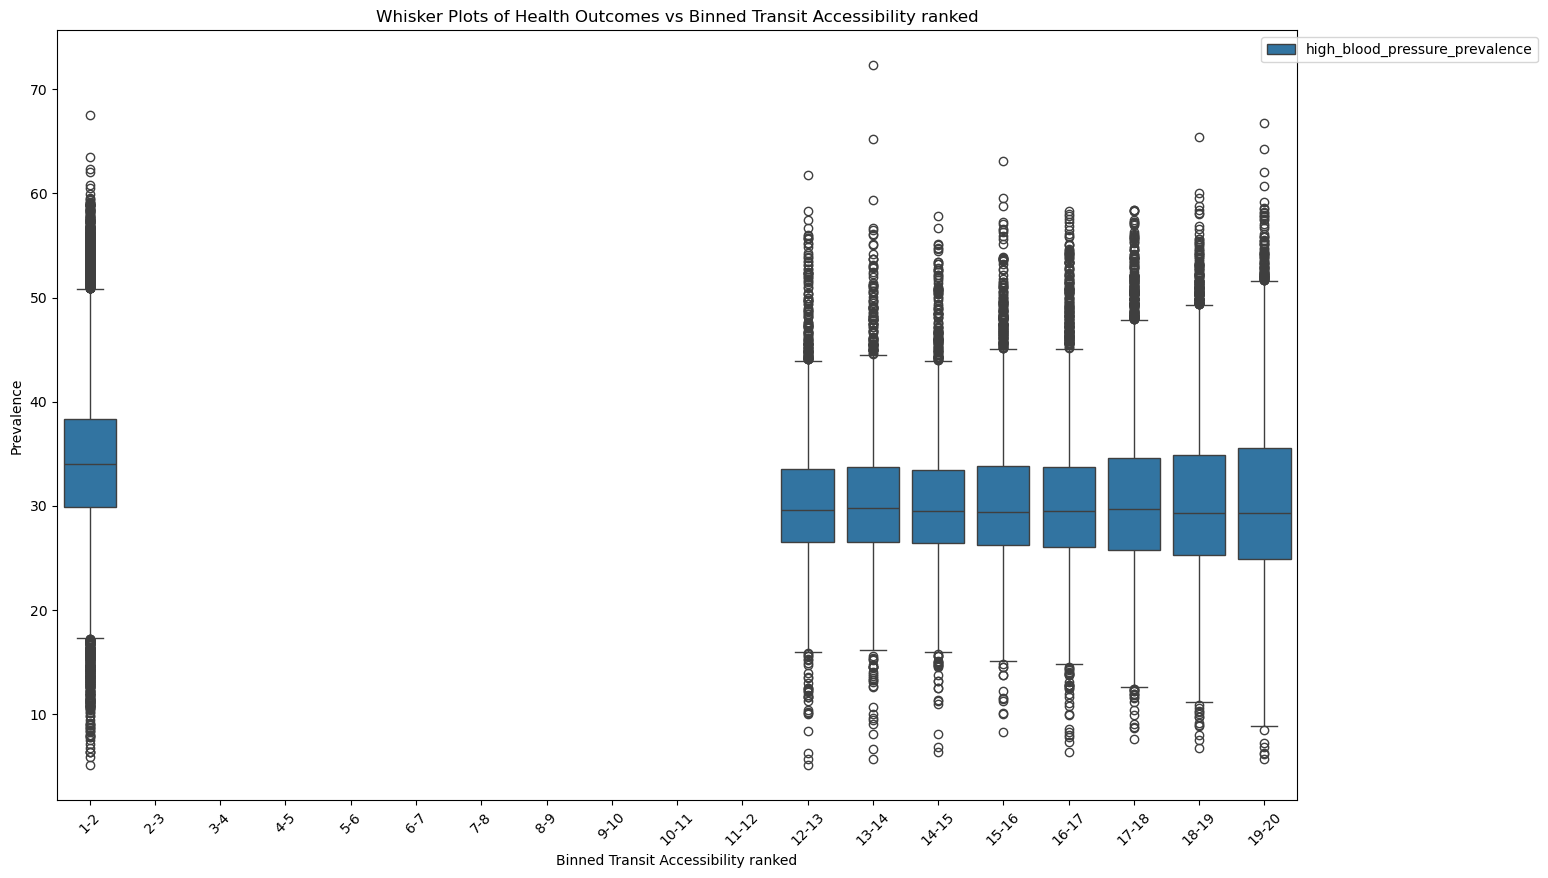

depression_prevalence


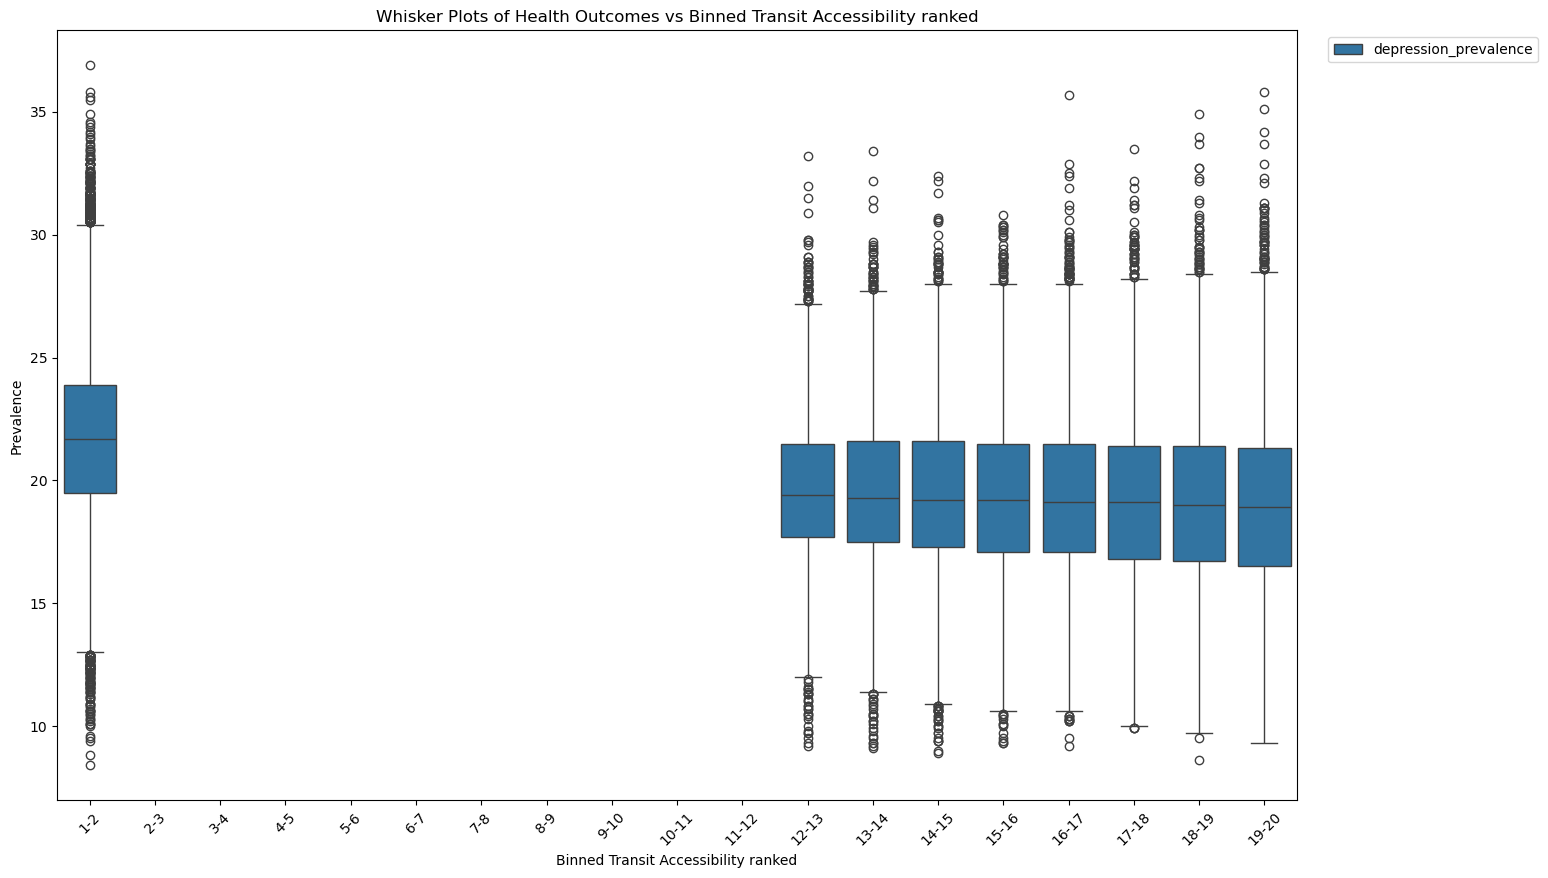

high_cholesterol_prevalence


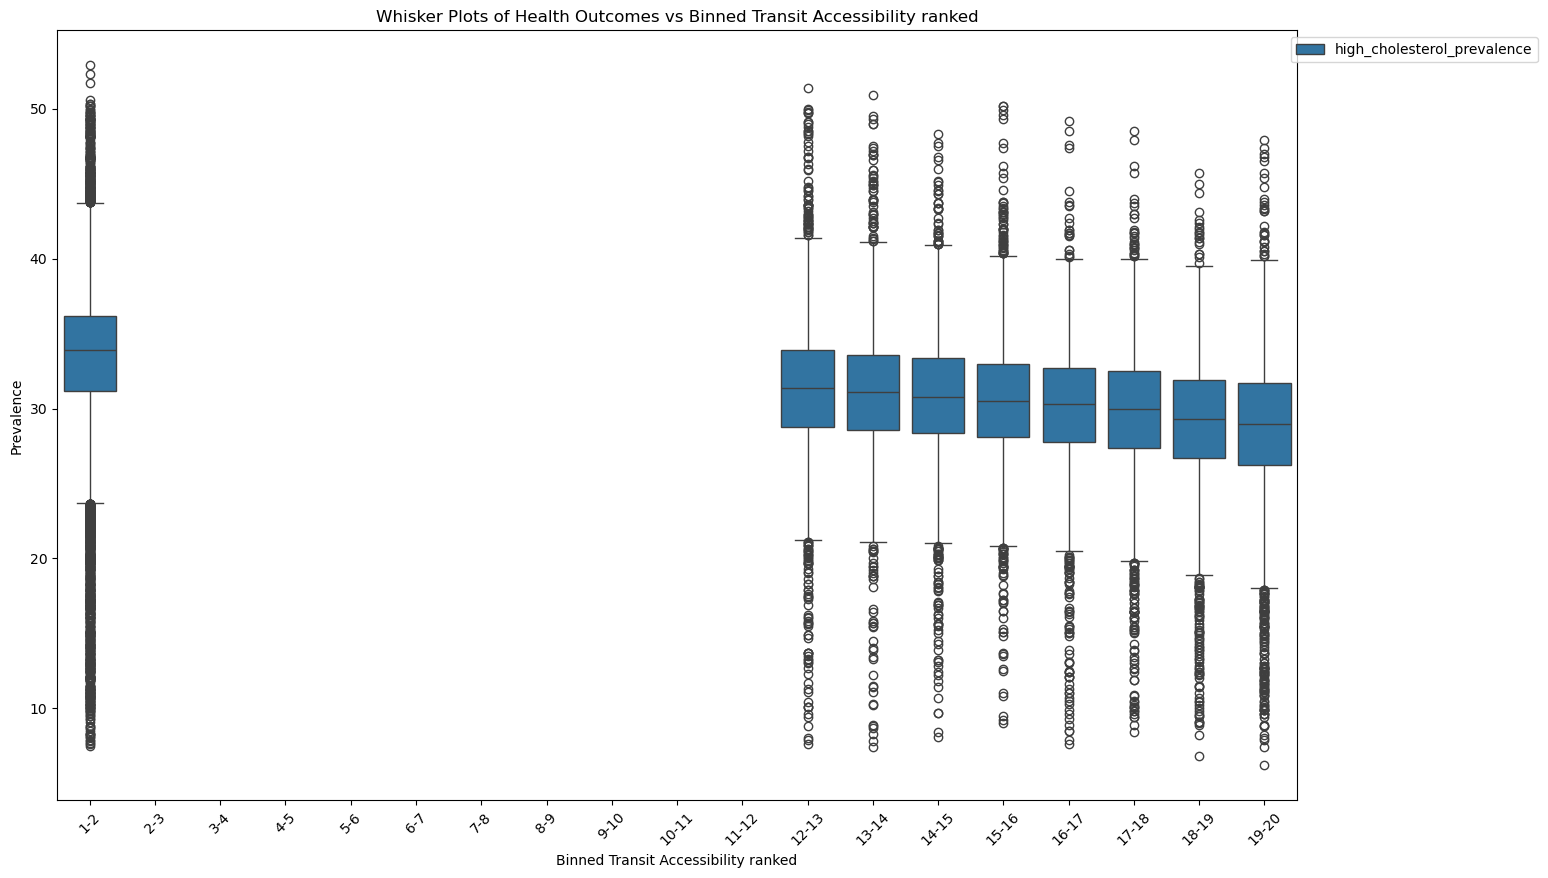

cancer_prevalence


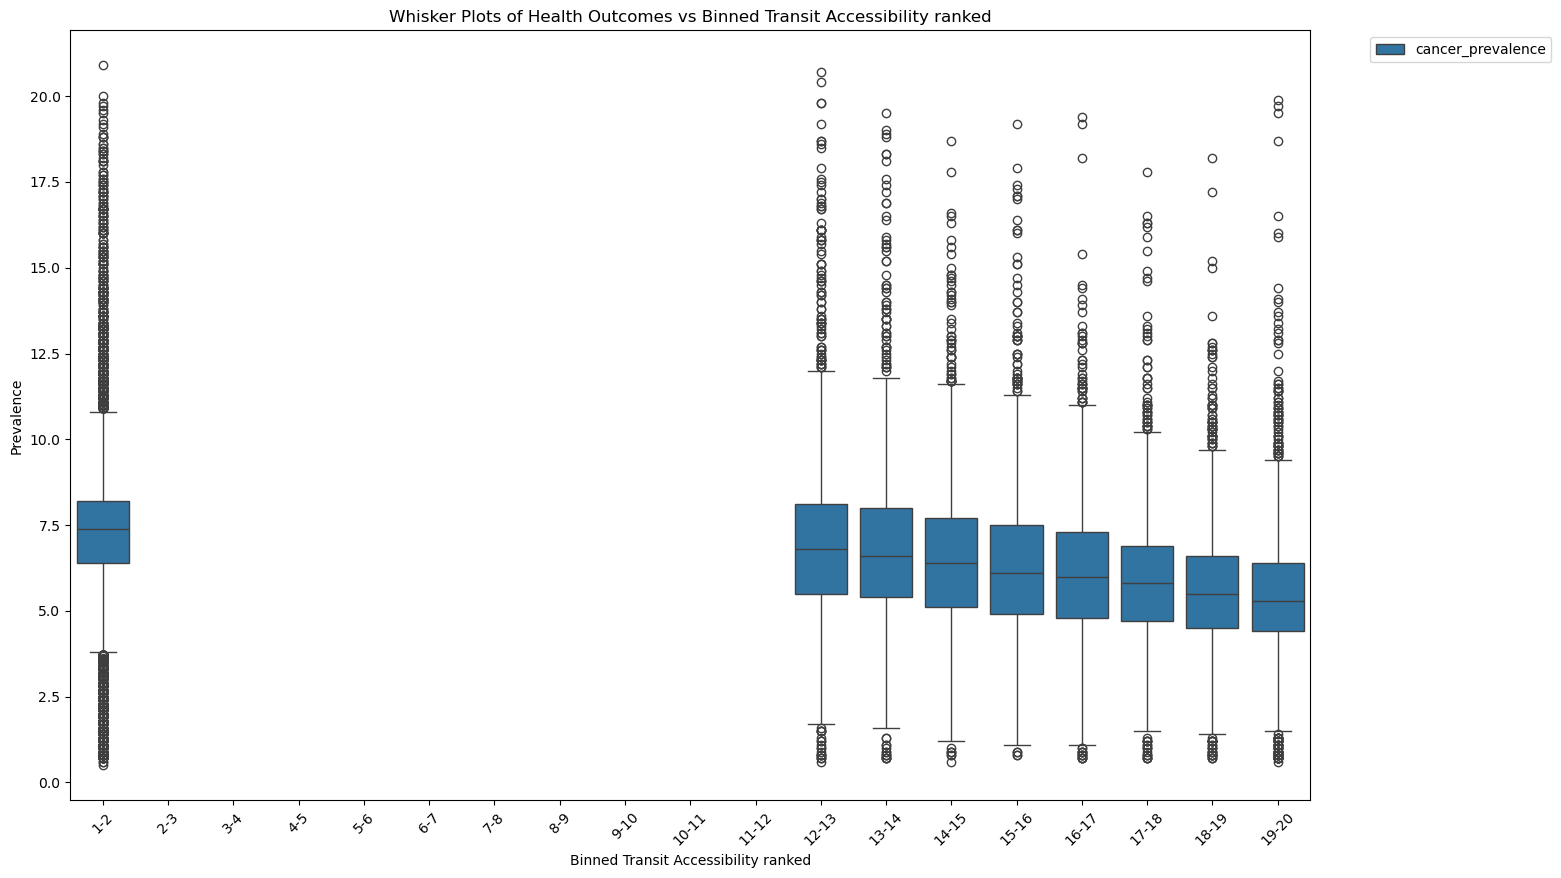

current_asthma_prevalence


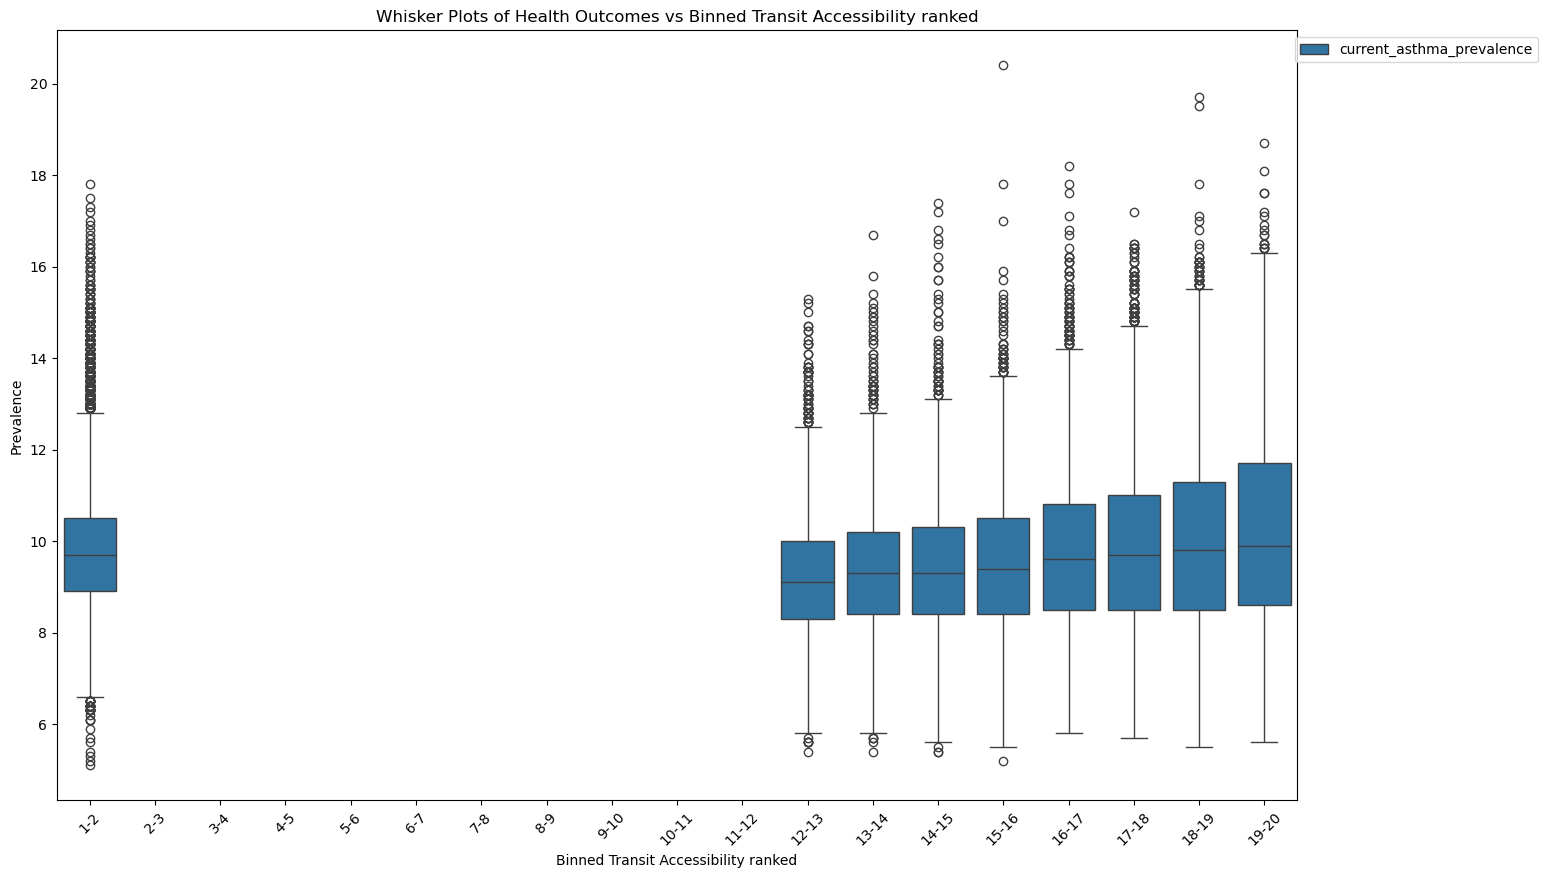

coronary_heart_disease_prevalence


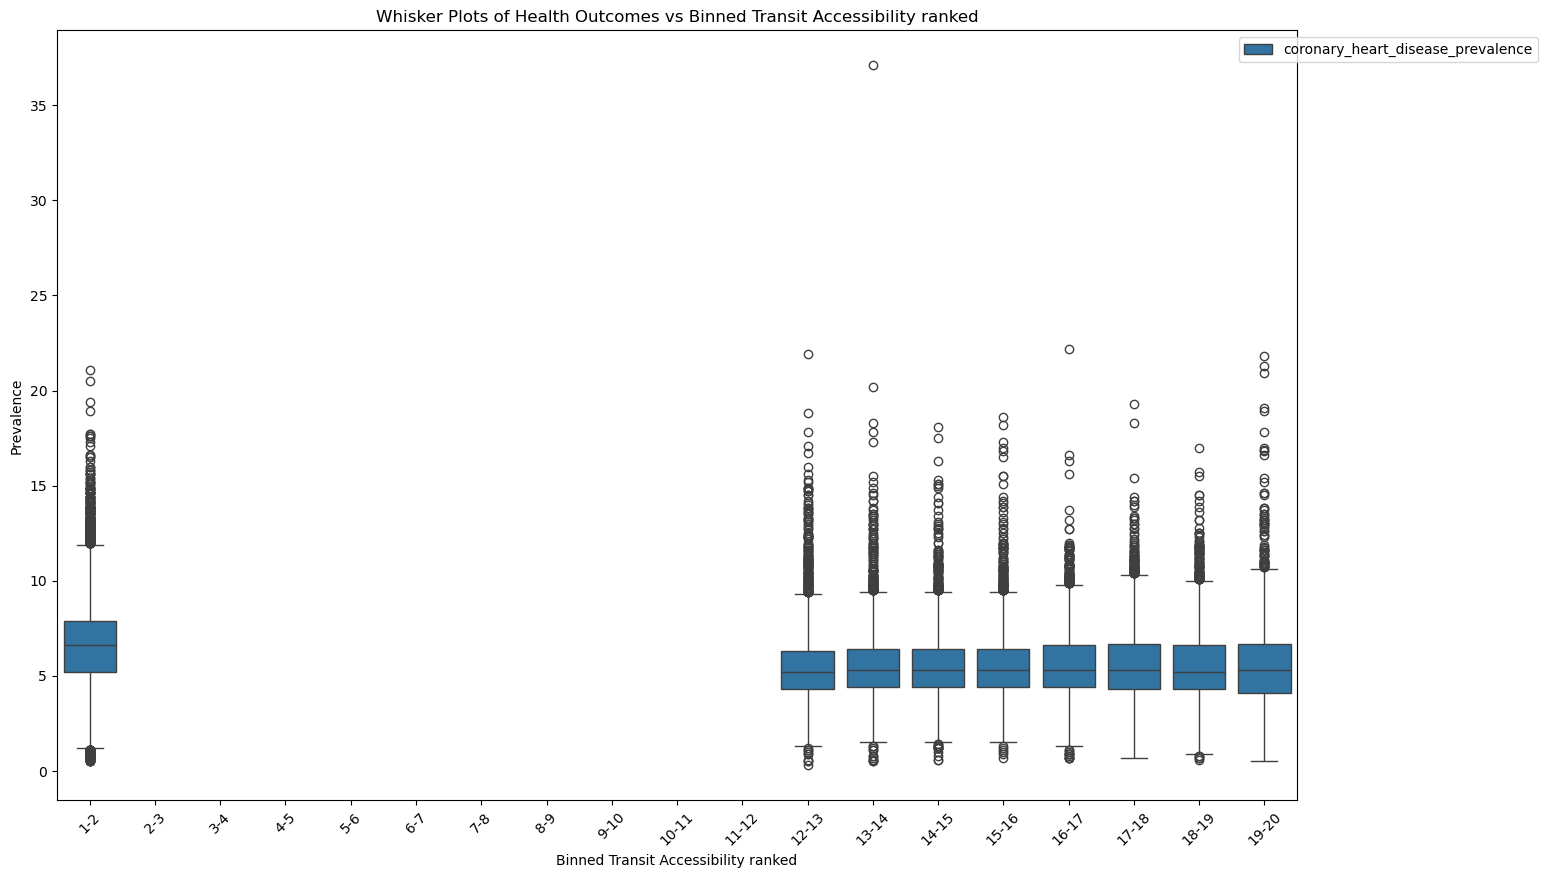

stroke_prevalence


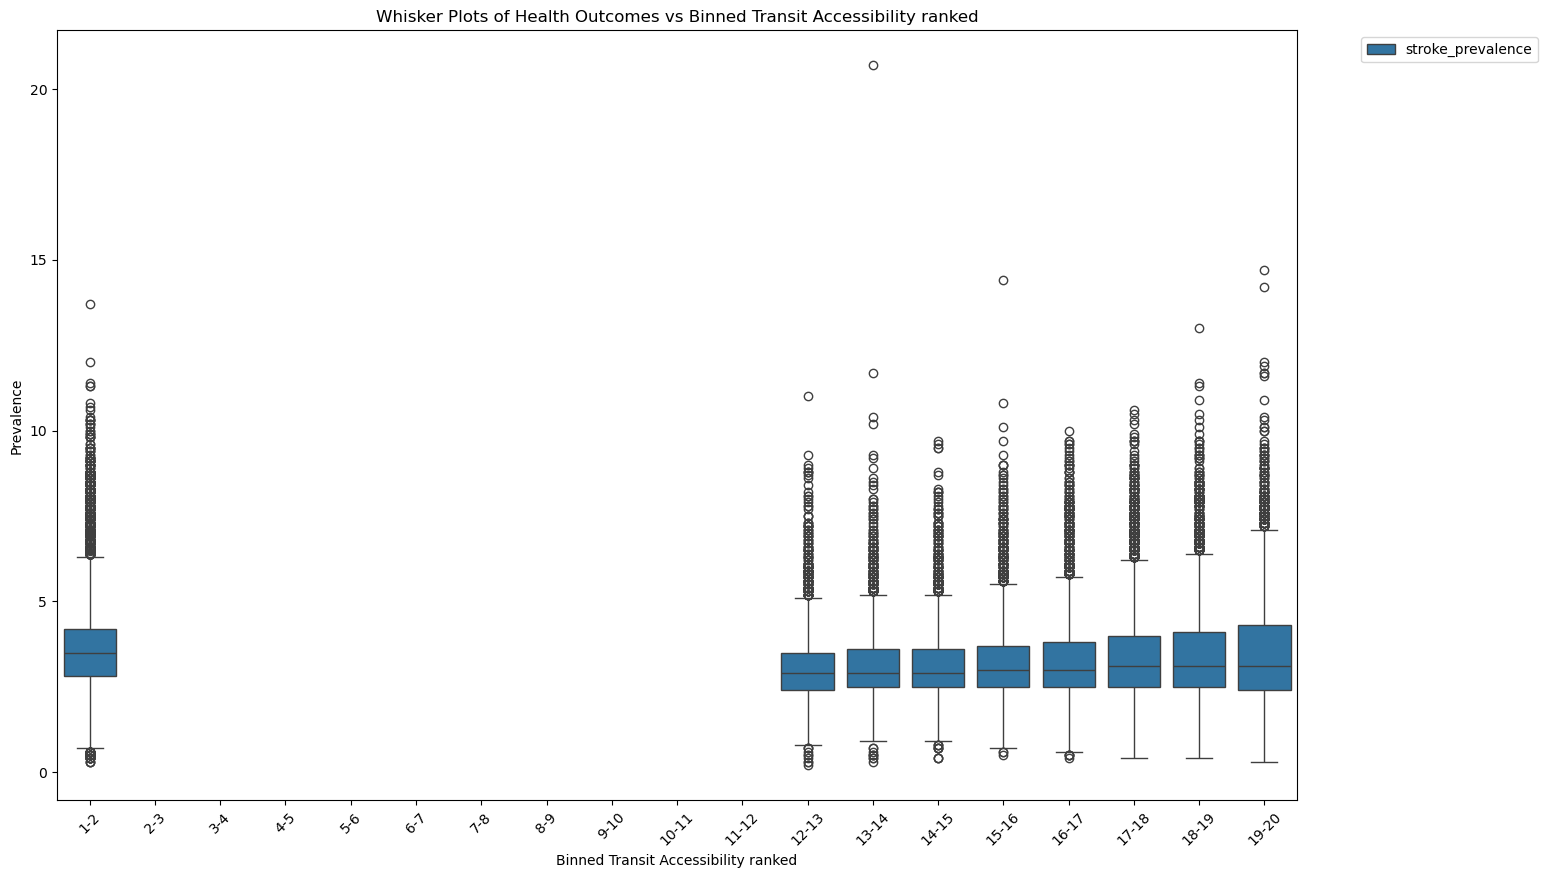

In [37]:
# Bin the 'transit_accessibility_ranked` into intervals from 1-2, 2-3, ..., up to 20
bins = [i for i in range(1, 21)]  # Create bins from 1 to 21
bin_labels = [f"{i}-{i+1}" for i in range(1, 20)]  # Create labels like 1-2, 2-3, ..., 19-20

for i in health_outcomes_columns:
    print(i)
    # Create a new column for the binned data
    df['transit_accessibility_ranked_bin'] = pd.cut(df['transit_accessibility_ranked'], bins=bins, labels=bin_labels, right=False)

    # Reshape the data into a long format to plot all health outcomes together
    df_long = df.melt(id_vars=["transit_accessibility_ranked_bin"], value_vars= i, 
                  var_name="health_outcome", value_name="prevalence")

# Plot the whisker plots for health outcomes across binned data
    plt.figure(figsize=(16, 10))
    sns.boxplot(x="transit_accessibility_ranked_bin", y="prevalence", hue="health_outcome", data=df_long)

# Improve readability
    plt.xticks(rotation=45)  # Rotate x-axis labels for clarity
    plt.title("Whisker Plots of Health Outcomes vs Binned Transit Accessibility ranked")
    plt.xlabel("Binned Transit Accessibility ranked")
    plt.ylabel("Prevalence")
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()

## Partial & Pearson Correlations

Pearson correlations is the overall correlation between two random variables. It also accounts for the indirect corrrelations arising via other parameters for two given paramaters. Partial correlations on the other hand, is the intrinsic correlation and is thus obtained by taking Pearson correlation and subtracting other possible indirect correlations with other parameters.

Thus, to analyze the intrinsic the correlation b/w health outcomes and walkability features, we also include socioeconomic data in the correlation matrix and primarily focus on partial correlation.

In [77]:
socioeconomic_columns = ['percent_unemployed', 'median_income','percent_below_poverty', 'percent_over_65','percent_bachelor_and_higher']

#health outcomes to be studied

health_outcomes_columns = [
    'obesity_prevalence',
    'diabetes_prevalence',
    'high_blood_pressure_prevalence',
    'depression_prevalence',
    'high_cholesterol_prevalence',
    'cancer_prevalence',
    'current_asthma_prevalence',
    'coronary_heart_disease_prevalence',
    'stroke_prevalence'
]

walkability_features = ['walkability_index','employment_mix_ranked',
       'employment_residential_mix_ranked', 'intersection_density_ranked',
       'transit_accessibility_ranked']

In [145]:
# function that compute and plot  partial correlations
def correlation_partial(data, group1_var, group2_var, title):
    corr = data[group1_var+group2_var].pcorr().loc[group1_var, group2_var]

    plt.figure(figsize=(10, 1))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
    plt.xticks(fontsize=10)  # reduce x-axis tick font size
    plt.yticks(fontsize=10)
    plt.title(title, fontsize=12)
    plt.show()

    corr_long = corr.stack().reset_index()
    corr_long.columns = ['var1', 'var2', 'correlation']
    corr_long['abs_corr'] = corr_long['correlation'].abs()
    corr_long = corr_long.sort_values('abs_corr', ascending=False)

    return corr_long

In [147]:
# function that compute and plot correlations
def correlation_pearson(data, group1_var, group2_var, title):
    corr = data[group1_var+group2_var].corr().loc[group1_var, group2_var]

    plt.figure(figsize=(10, 1))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
    plt.xticks(fontsize=10)  # reduce x-axis tick font size
    plt.yticks(fontsize=10)
    plt.title(title, fontsize=12)
    plt.show()

    corr_long = corr.stack().reset_index()
    corr_long.columns = ['var1', 'var2', 'correlation']
    corr_long['abs_corr'] = corr_long['correlation'].abs()
    corr_long = corr_long.sort_values('abs_corr', ascending=False)

    return corr_long

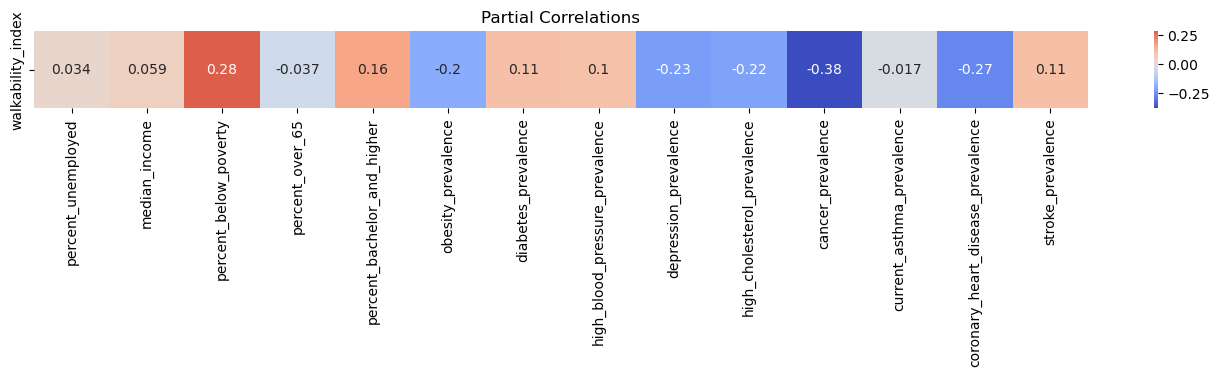

In [96]:
# Walkability vs health correlation (partial correlation)
walkability_health_cor = correlation_partial(df, ['walkability_index'], socioeconomic_data+health_outcomes_columns, 'Partial Correlations')

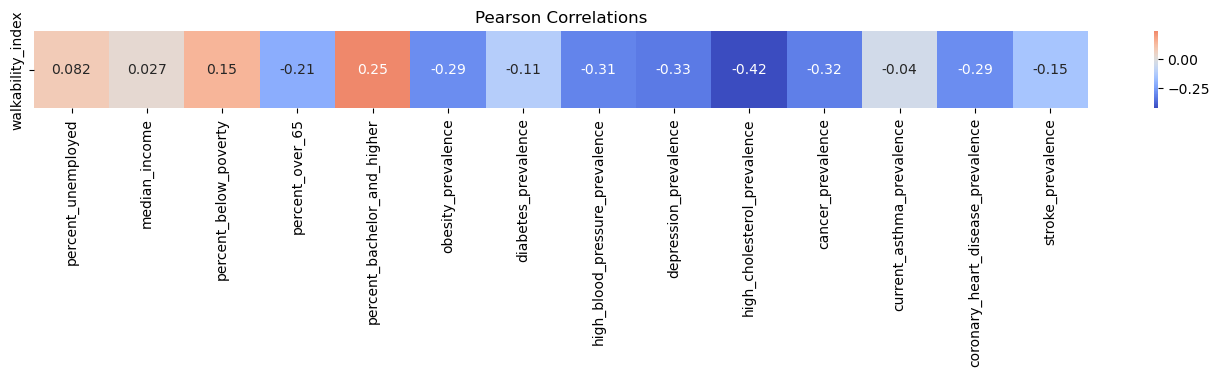

In [97]:
# Walkability vs health correlation (pearson correlation)
walkability_health_cor = correlation_pearson(df, ['walkability_index'], socioeconomic_data+health_outcomes_columns, 'Pearson Correlations')

From the partial correlation graph, we observe a mild inverse correlation between the walkability index and health outcomes: obesity, depression, high cholestrol, cancer and high blood pressure, even after taking the socioeconomics data into account.

### Correlations with features

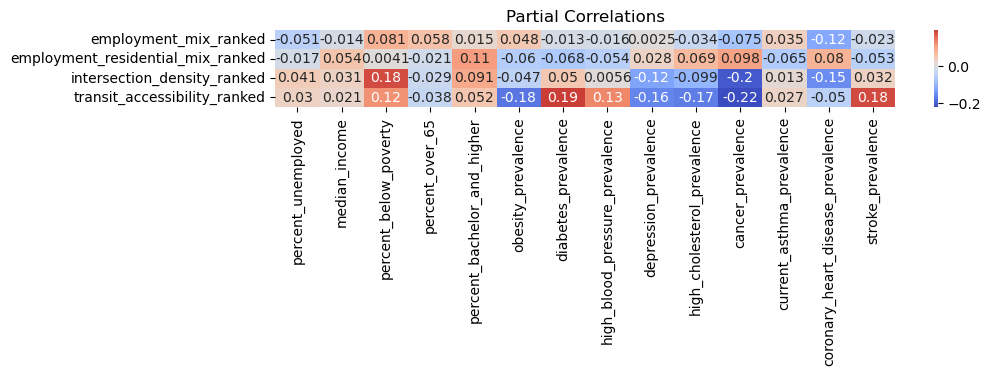

In [153]:
walkability_health_cor = correlation_partial(df, ['employment_mix_ranked',
       'employment_residential_mix_ranked', 'intersection_density_ranked',
       'transit_accessibility_ranked'], socioeconomic_data+health_outcomes_columns, 'Partial Correlations')

In [154]:
print('Top 10 Walkability-Health correlations:')
print(walkability_health_cor.head(10))

Top 10 Walkability-Health correlations:
                            var1                               var2  \
52  transit_accessibility_ranked                  cancer_prevalence   
38   intersection_density_ranked                  cancer_prevalence   
48  transit_accessibility_ranked                diabetes_prevalence   
55  transit_accessibility_ranked                  stroke_prevalence   
30   intersection_density_ranked              percent_below_poverty   
47  transit_accessibility_ranked                 obesity_prevalence   
51  transit_accessibility_ranked        high_cholesterol_prevalence   
50  transit_accessibility_ranked              depression_prevalence   
40   intersection_density_ranked  coronary_heart_disease_prevalence   
49  transit_accessibility_ranked     high_blood_pressure_prevalence   

    correlation  abs_corr  
52    -0.219351  0.219351  
38    -0.203942  0.203942  
48     0.191508  0.191508  
55     0.181806  0.181806  
30     0.179834  0.179834  
47    -0.1

From the partial correlations, we see transit accessibility and intersection density as the most significant feature.